# **Data Visualization Notebook**

## **0. Library import**

This section imports the libraries needed for data analysis and visualization, including pandas for data processing, matplotlib, and seaborn for chart generation, along with custom modules from the project.

In [1]:
import os
import sys
# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import BRFSS_FILTERING_FILE_PATH
from src.visualization import (
    plot_feature_distributions_comparison,
    plot_diabetes_distribution_by_indicators,
    plot_correlation_matrix,
    plot_class_distribution
)

plt.style.use("seaborn-v0_8")

## **1. Load dataset**

Download preprocessed and filtered BRFSS data. This dataset contains information on behavioral and health factors that may influence the diabetes status of survey participants.

In [2]:
# Read dataset
df = pd.read_csv(BRFSS_FILTERING_FILE_PATH)
df.head()

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Year
0,2.0,1.0,1.0,1.0,27.0,0.0,0.0,0.0,1.0,0.0,...,0.0,2.0,0.0,0.0,1.0,0.0,11.0,6.0,6.0,2017
1,0.0,1.0,0.0,1.0,29.0,0.0,0.0,0.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,1.0,10.0,6.0,8.0,2017
2,0.0,0.0,0.0,1.0,23.0,1.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,14.0,0.0,0.0,10.0,2.0,2.0,2017
3,0.0,1.0,0.0,1.0,27.0,1.0,0.0,1.0,1.0,0.0,...,0.0,3.0,0.0,6.0,0.0,1.0,12.0,4.0,4.0,2017
4,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,1.0,10.0,5.0,8.0,2017


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787602 entries, 0 to 787601
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              787602 non-null  float64
 1   HighBP                787602 non-null  float64
 2   HighChol              787602 non-null  float64
 3   CholCheck             787602 non-null  float64
 4   BMI                   787602 non-null  float64
 5   Smoker                787602 non-null  float64
 6   Stroke                787602 non-null  float64
 7   HeartDiseaseorAttack  787602 non-null  float64
 8   PhysActivity          787602 non-null  float64
 9   HvyAlcoholConsump     787602 non-null  float64
 10  AnyHealthcare         787602 non-null  float64
 11  NoDocbcCost           787602 non-null  float64
 12  GenHlth               787602 non-null  float64
 13  MentHlth              787602 non-null  float64
 14  PhysHlth              787602 non-null  float64
 15  

## **2. Visualization**

The main part of this notebook will perform visual analysis to explore:
- Distribution of features over years
- Relationship between health indicators and diabetes status
- Interactions between different factors
- Trends over time

In [4]:
# Split data by year
df_2017 = df[df["Year"] == 2017].copy()
df_2019 = df[df["Year"] == 2019].copy()
df_2021 = df[df["Year"] == 2021].copy()

### **2.1 Feature distribution over years**

This section analyzes the distribution of key characteristics across 2017, 2019, and 2021. This helps us understand how health and behavioral factors in the population have changed over time.

#### **2.1.1 BMI distribution over the years**

- **Non-diabetic group (Diabetes = 0)**: The BMI distribution is normally distributed with a peak centered around 25–27, corresponding to the WHO classification of "overweight." This indicates that the majority of non-diabetic individuals have a BMI in the normal to mildly overweight range.
- **Pre-diabetic group (Diabetes = 1)**: The BMI distribution is shifted to the right with a peak around 28–30, indicating a higher BMI trend compared to the non-diabetic group. This is a warning sign of the link between overweight and the risk of developing diabetes.
- **Diabetes group (Diabetes = 2)**: The highest BMI distribution has a peak around 30–32 (WHO class I obesity). This confirms the strong correlation between obesity and type 2 diabetes. Over 3 years, this trend has remained stable, indicating that BMI is a sustainable risk factor.

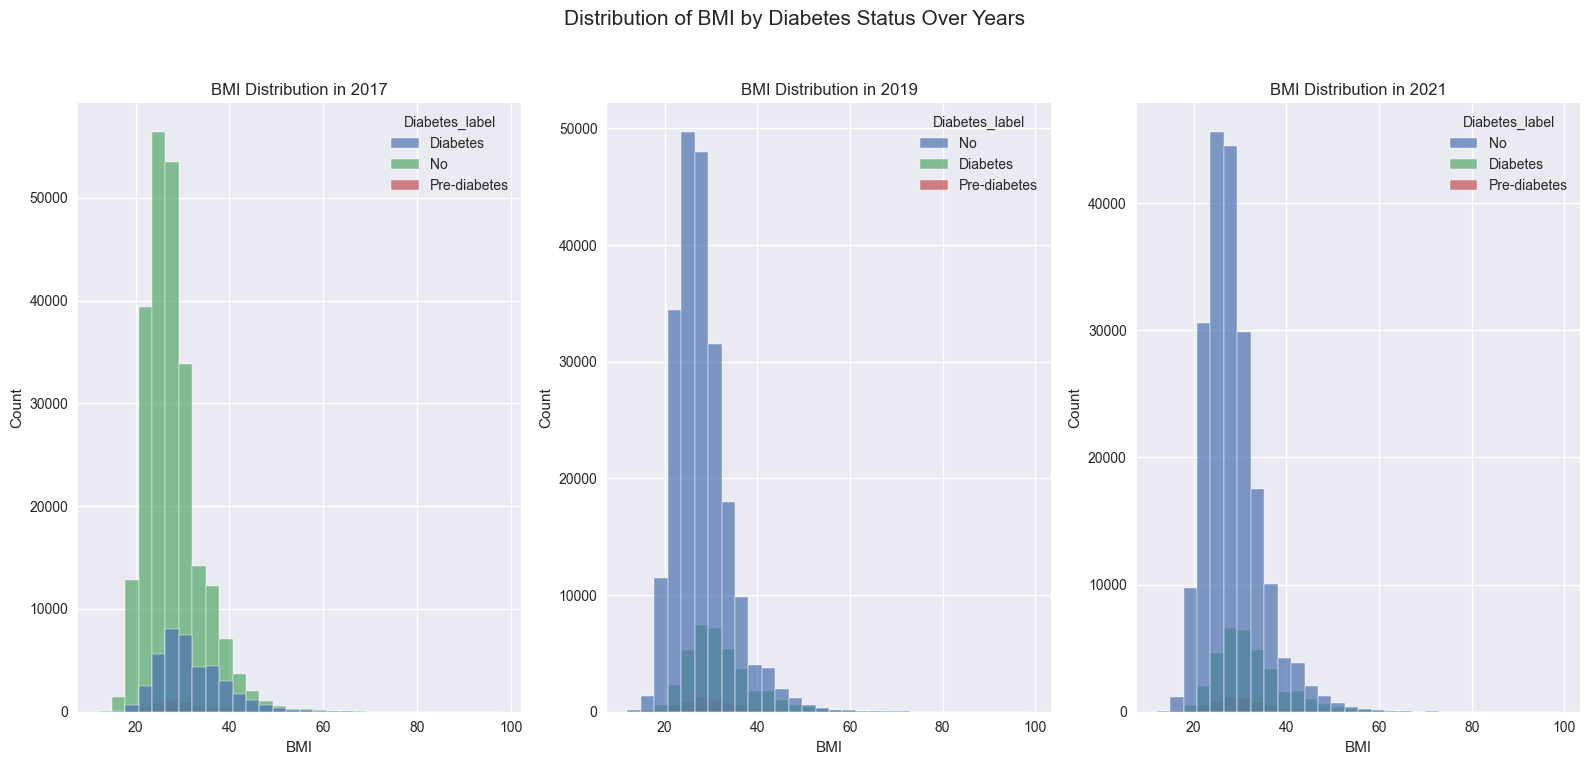

In [5]:
# Distribution of BMI by Diabetes status over years
plot_feature_distributions_comparison(
    df_list=[df_2017, df_2019, df_2021],
    year_list=[2017, 2019, 2021],
    feature="BMI",
)

#### **2.1.2 Age distribution**

Age distribution analysis shows:

- **Increasing trend with age**: Diabetes prevalence increases significantly with age. The 18–34 age group has the lowest diabetes prevalence (<5%), while the 65+ group has the highest prevalence (>25%). This reflects the natural aging process of the pancreas and decreased insulin sensitivity with age.

- **High-risk group**: From 45 years of age, diabetes prevalence increases significantly, especially in the 55–64 age group with a sharp increase in both prediabetes and diabetes. This trend has been stable over 3 years, confirming age as the most important non-modifiable risk factor.

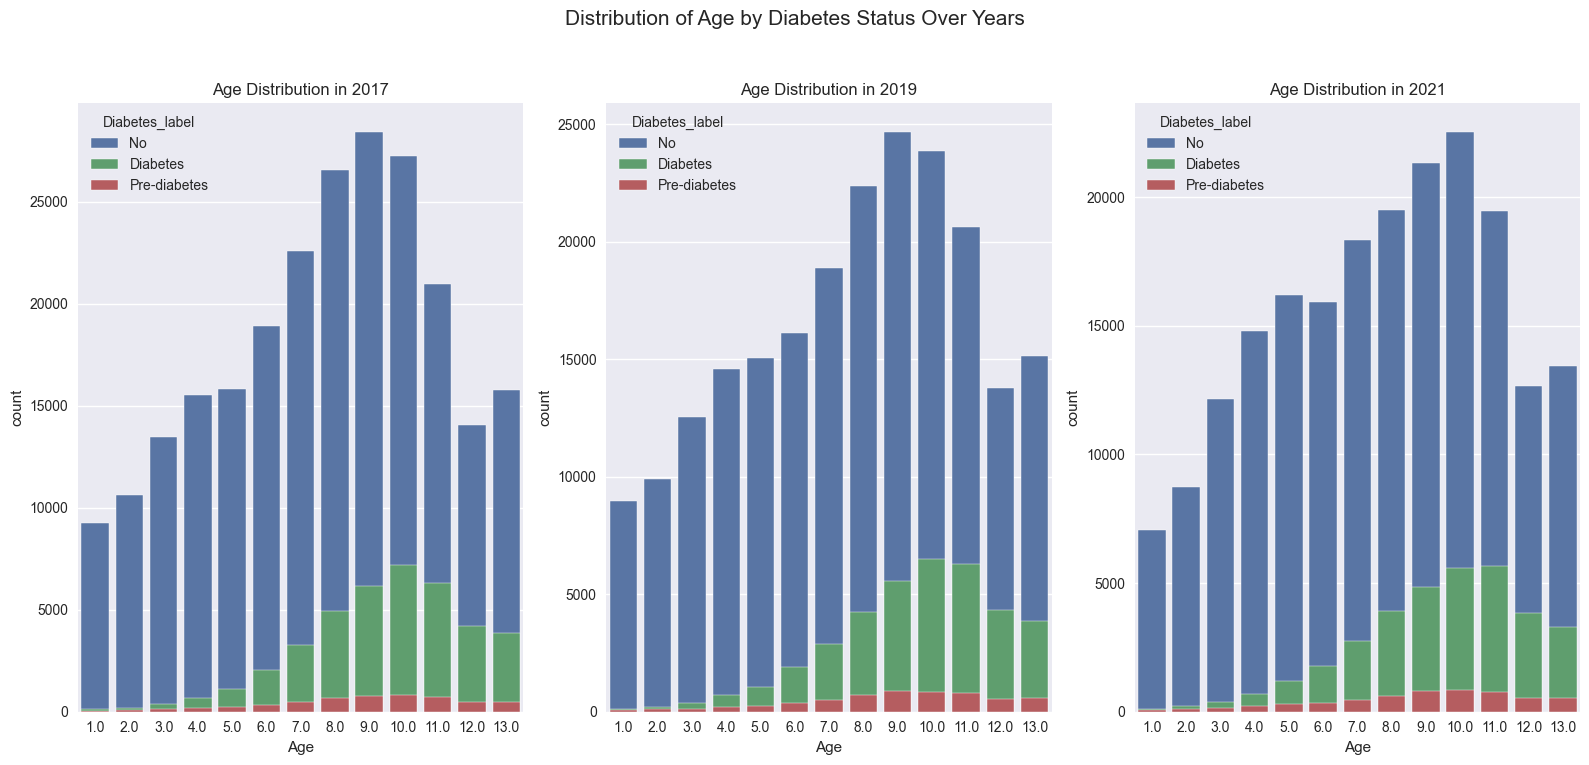

In [6]:
# Distribution of Age by Diabetes status over years
plot_feature_distributions_comparison(
    df_list=[df_2017, df_2019, df_2021],
    year_list=[2017, 2019, 2021],
    feature="Age"
)

#### **2.1.3 General health status (GenHlth)**

There was a clear inverse correlation between self-reported health and diabetes prevalence:

- **Good health (GenHlth = 1–2)**: Those with “excellent” and “very good” health had a diabetes prevalence of <10%, indicating a correct perception of their own health status.
- **Poor health (GenHlth = 4–5)**: Those who rated their health as “average” and “poor” had a 3–4 times higher diabetes prevalence, reaching 25–35%. This reflects the impact of diabetes on quality of life and self-assessment of the patient.

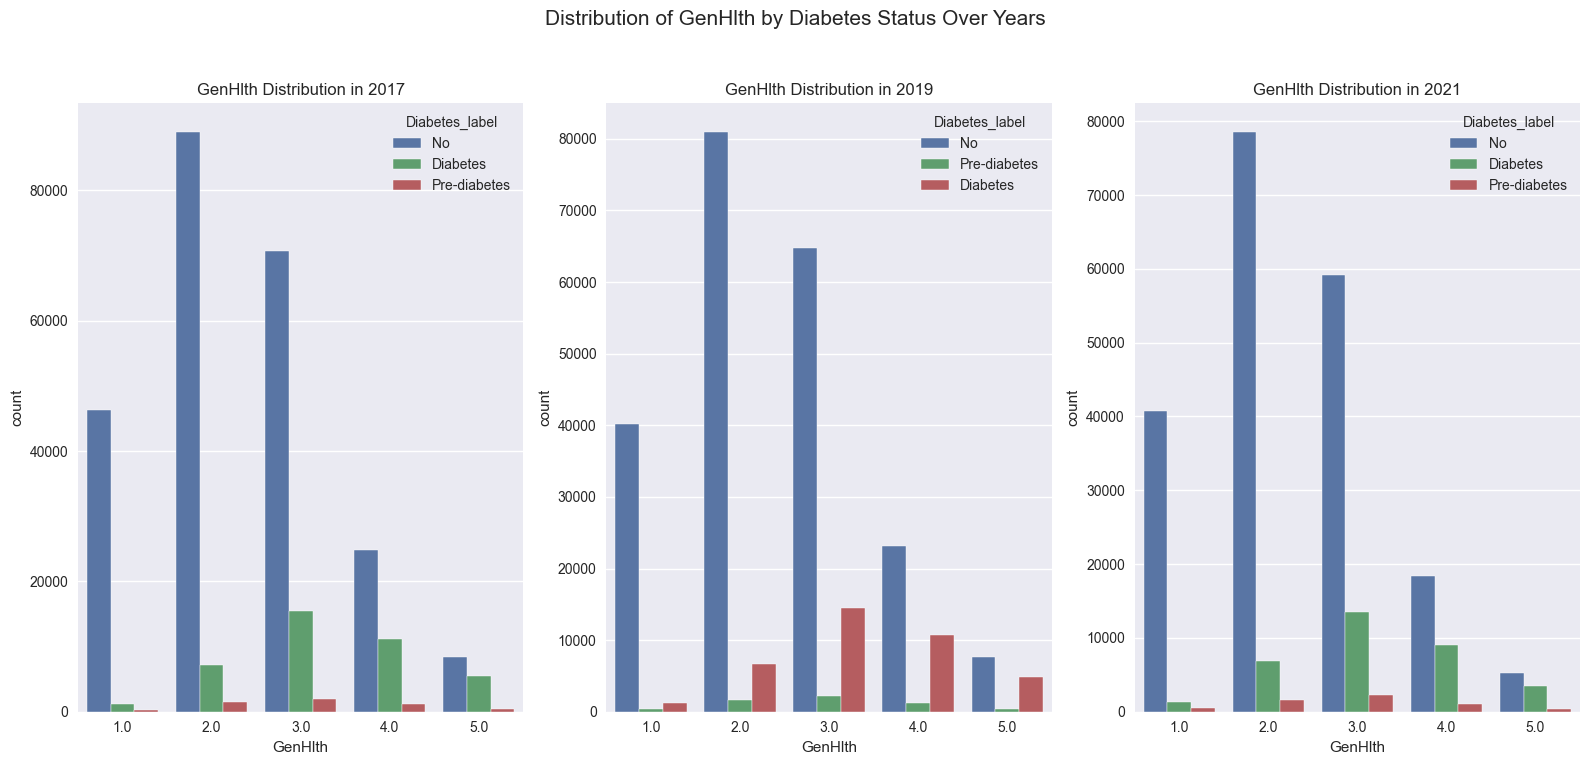

In [7]:
# Distribution of General Health by Diabetes status over years
plot_feature_distributions_comparison(
    df_list=[df_2017, df_2019, df_2021],
    year_list=[2017, 2019, 2021],
    feature="GenHlth"
)

#### **2.1.4 Access to health services (NoDocbcCost)**

Financial barriers to seeing a doctor show:

- **Group not financially constrained (NoDocbcCost = 0)**: Have lower rates of diabetes and are diagnosed earlier, leading to better management of the disease.
- **Group financially constrained (NoDocbcCost = 1)**: Tend to have higher rates of undiagnosed diabetes or late diagnosis, leading to more severe disease when detected.

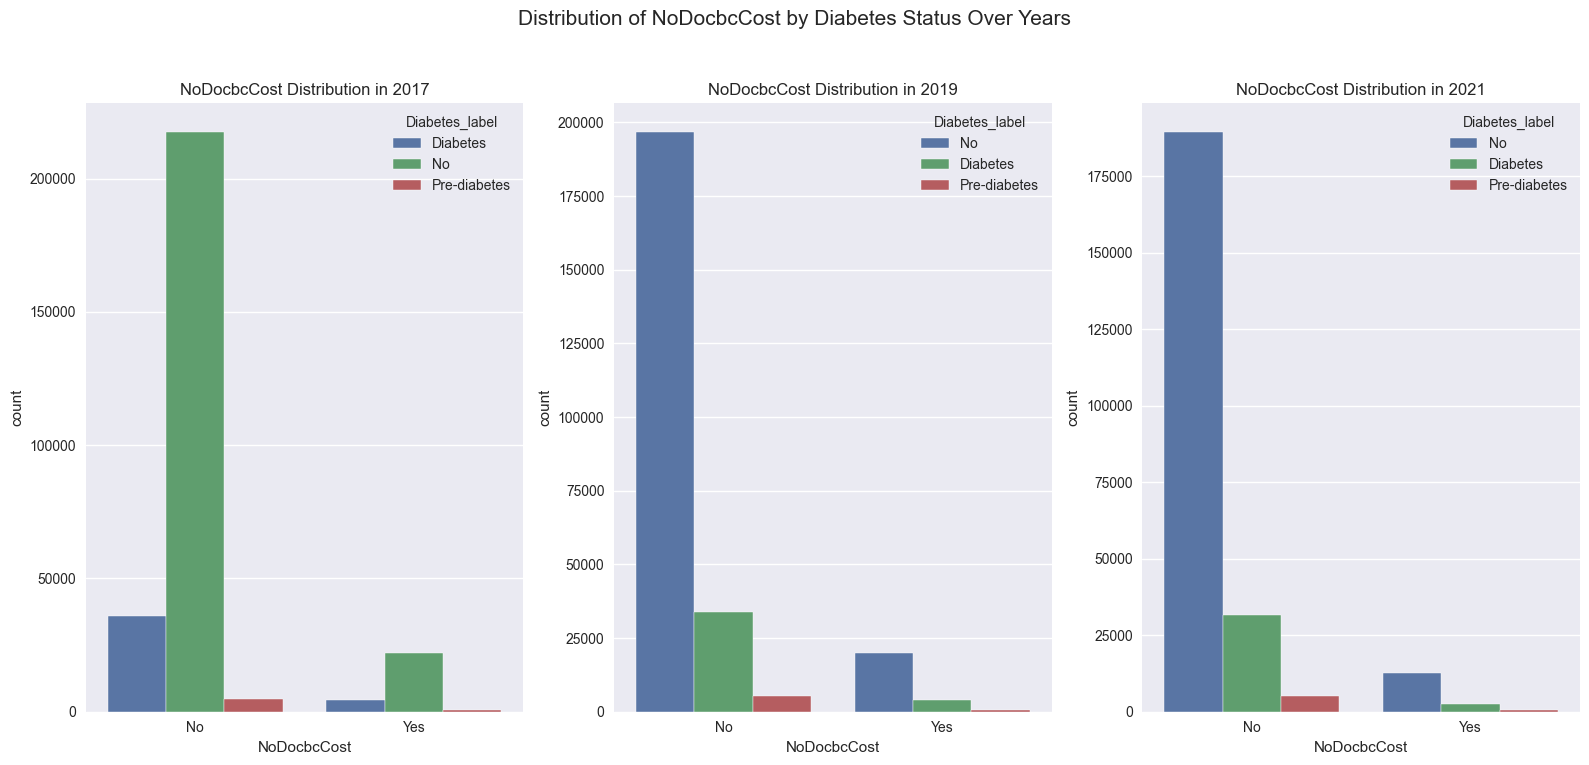

In [8]:
plot_feature_distributions_comparison(
    df_list=[df_2017, df_2019, df_2021],
    year_list=[2017, 2019, 2021],
    feature="NoDocbcCost",
)

#### **2.1.5 Distribution of continuous features**

- **BMI**: Boxplot shows that the median BMI of the diabetes group (≈30) was significantly higher than that of the non-diabetic group (≈26). There were many outliers at high BMI (>40), mainly in the diabetes group, indicating that severe obesity is an extremely high risk factor.
- **Mental health (MentHlth)**: The diabetes group had a higher number of poor mental health days per month (median ≈5 days) than the non-diabetic group (≈2 days), reflecting the psychological burden of chronic illness.
- **Physical health (PhysHlth)**: Similarly, the diabetes group had more poor physical health days, indicating the impact of diabetes complications on daily activities.

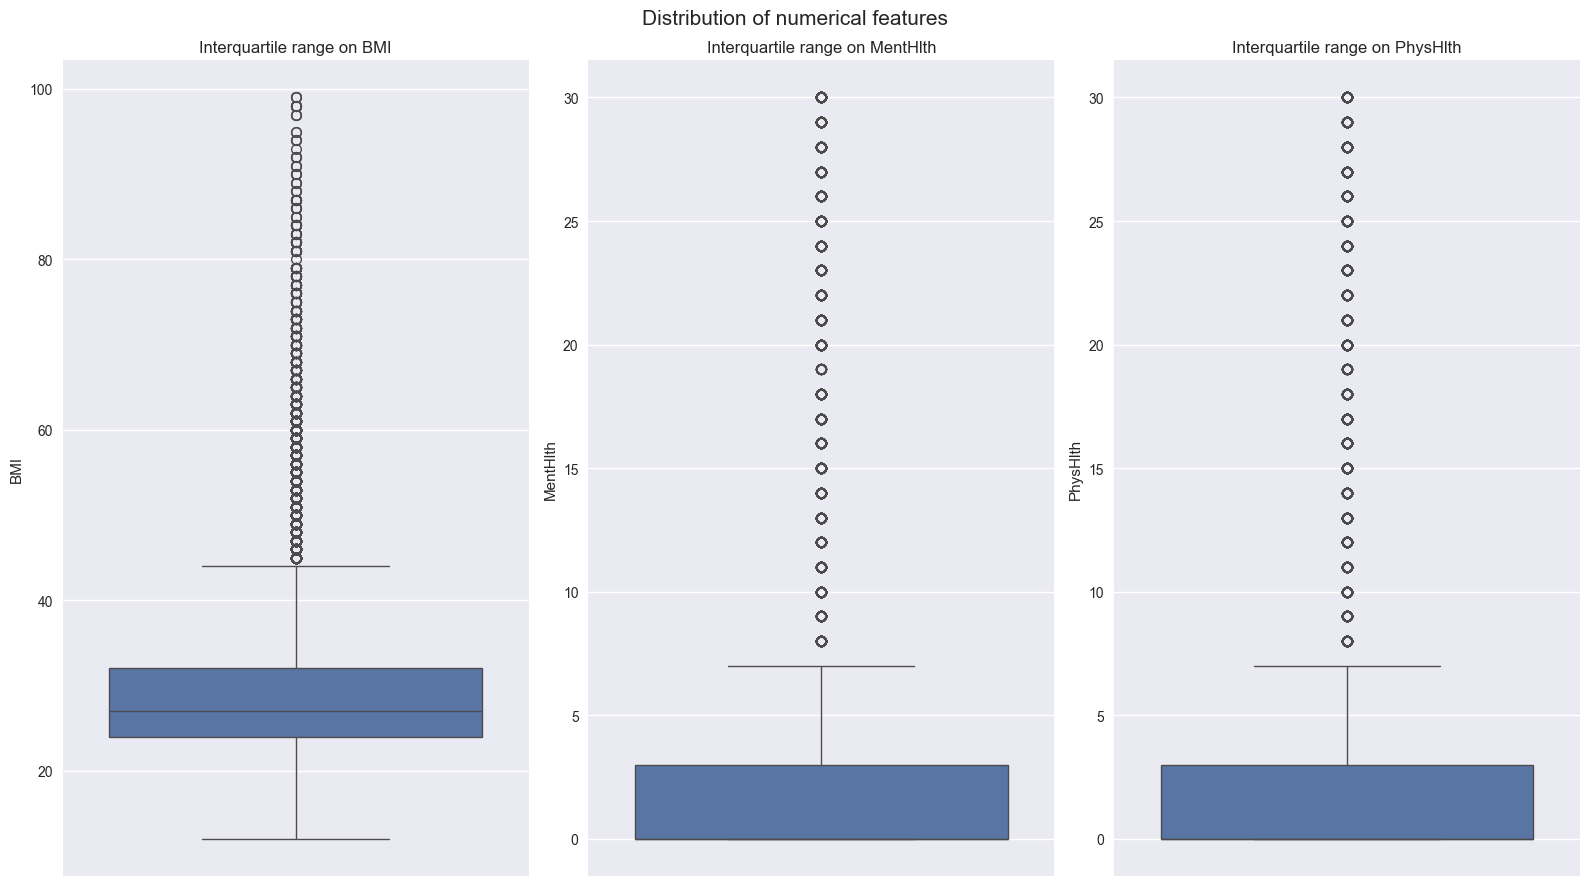

In [9]:
# Draw boxplot to identify outlier
fig, ax = plt.subplots(1, 3, figsize=(16, 9))

sns.boxplot(data=df, y='BMI', ax=ax[0])
ax[0].set_title('Interquartile range on BMI')

sns.boxplot(data=df, y='MentHlth', ax=ax[1])
ax[1].set_title('Interquartile range on MentHlth')

sns.boxplot(data=df, y='PhysHlth', ax=ax[2])
ax[2].set_title('Interquartile range on PhysHlth')

plt.suptitle("Distribution of numerical features", fontsize=15)
plt.tight_layout()
plt.show()

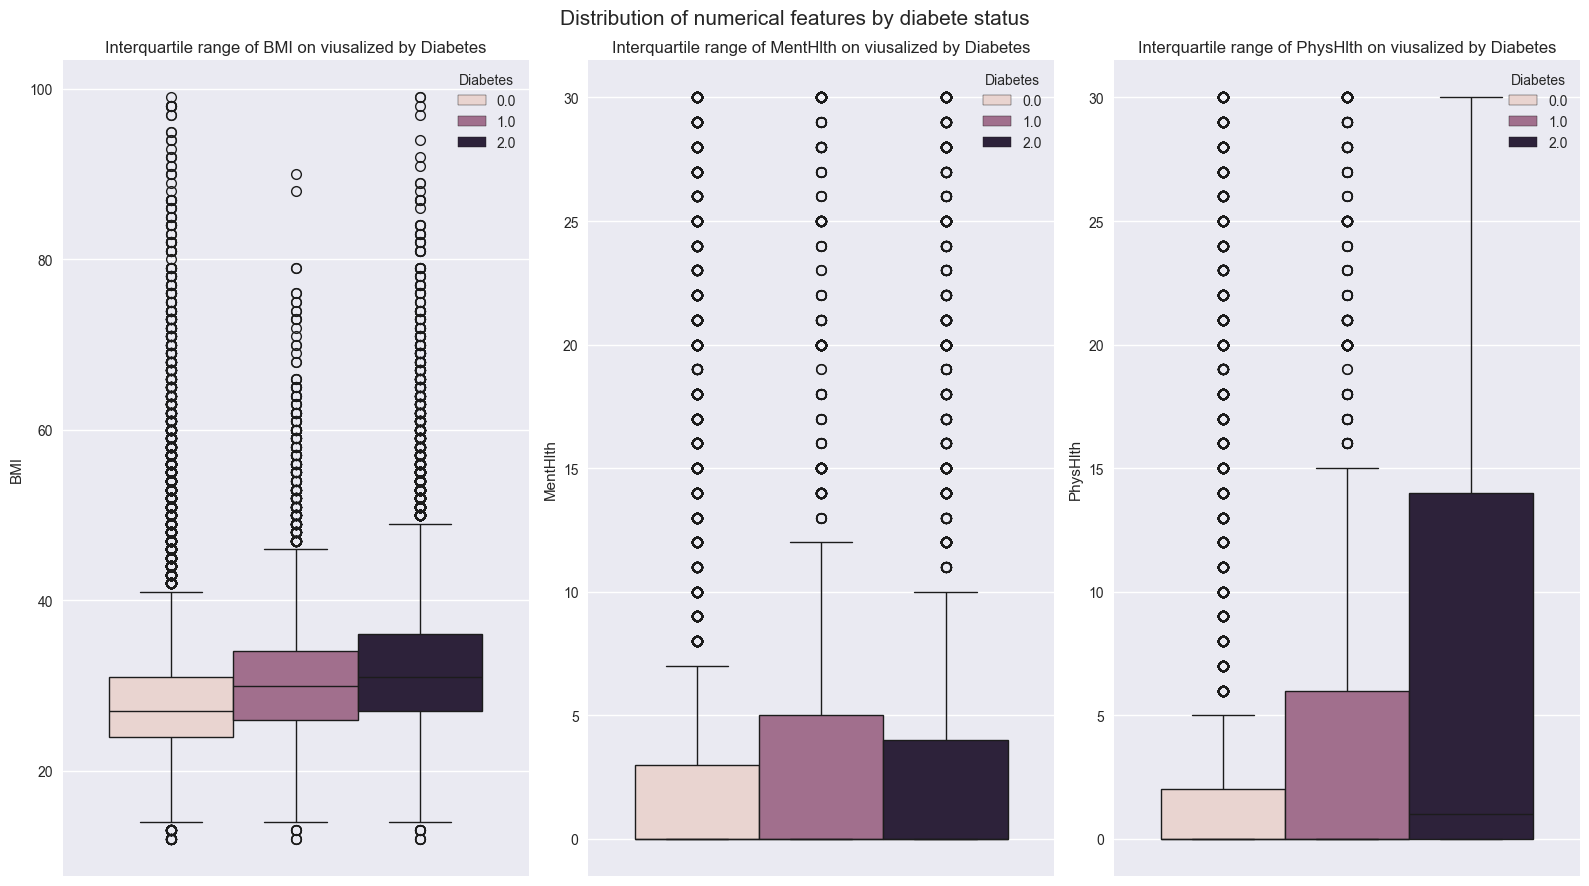

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 9))

sns.boxplot(data=df, y='BMI', hue='Diabetes', ax=ax[0])
ax[0].set_title('Interquartile range of BMI on viusalized by Diabetes')

sns.boxplot(data=df, y='MentHlth', hue='Diabetes', ax=ax[1])
ax[1].set_title('Interquartile range of MentHlth on viusalized by Diabetes')

sns.boxplot(data=df, y='PhysHlth', hue='Diabetes', ax=ax[2])
ax[2].set_title('Interquartile range of PhysHlth on viusalized by Diabetes')

plt.suptitle("Distribution of numerical features by diabete status", fontsize=15)
plt.tight_layout()
plt.show()

### **2.2 Physical health indicators over years**

Analysis over 3 years showed:

**High Blood Pressure (HighBP)**: There is a strong correlation with diabetes—about 65–70% of diabetics have high blood pressure, compared to only 25–30% of the non-diabetic group. This is a manifestation of metabolic syndrome.

**High Cholesterol (HighChol)**: The rate of high cholesterol in the diabetic group (≈50%) is twice that of the non-diabetic group (≈25%), reflecting the lipid disorders commonly found in diabetes.

**Difficulty walking (DiffWalk)**: The rate of difficulty moving in the diabetic group is 3–4 times higher, showing the impact of the disease on motor function and quality of life.

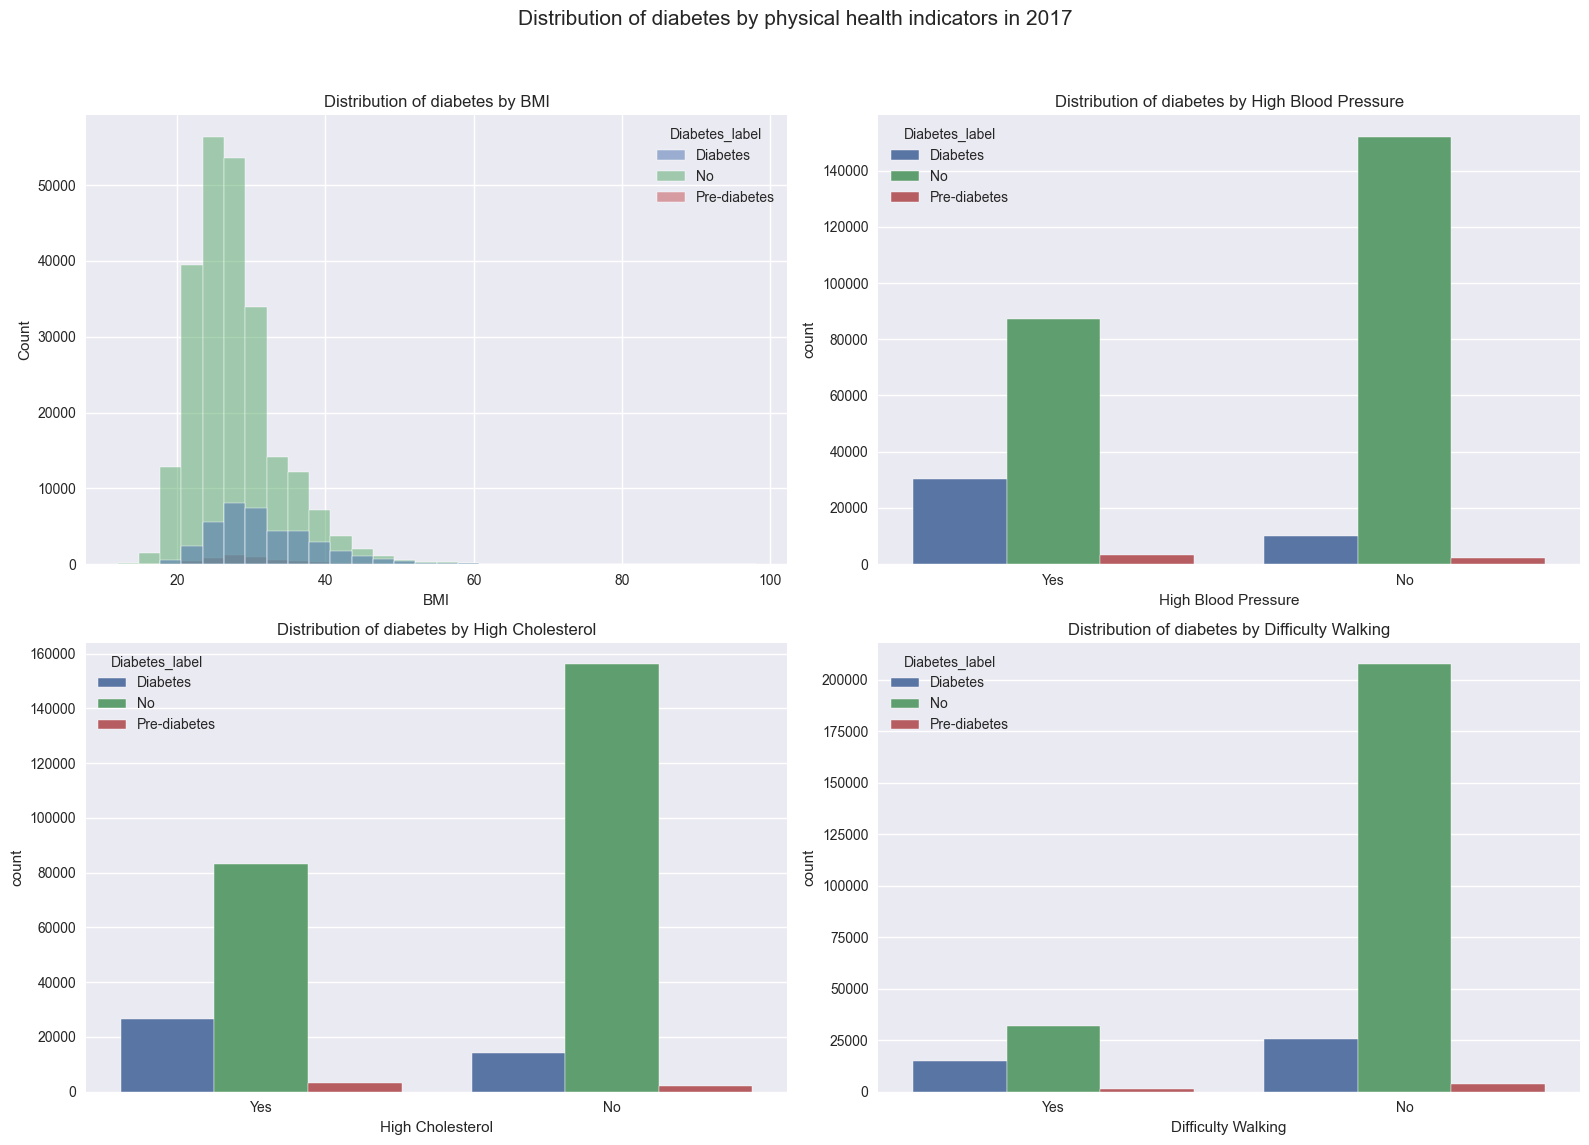

In [11]:
# Distribution of diabetes by physical health indicators in 2017
plot_diabetes_distribution_by_indicators(
    df=df_2017,
    indicators=["BMI", "HighBP", "HighChol", "DiffWalk"],
    year=2017,
    title="Distribution of diabetes by physical health indicators"
)

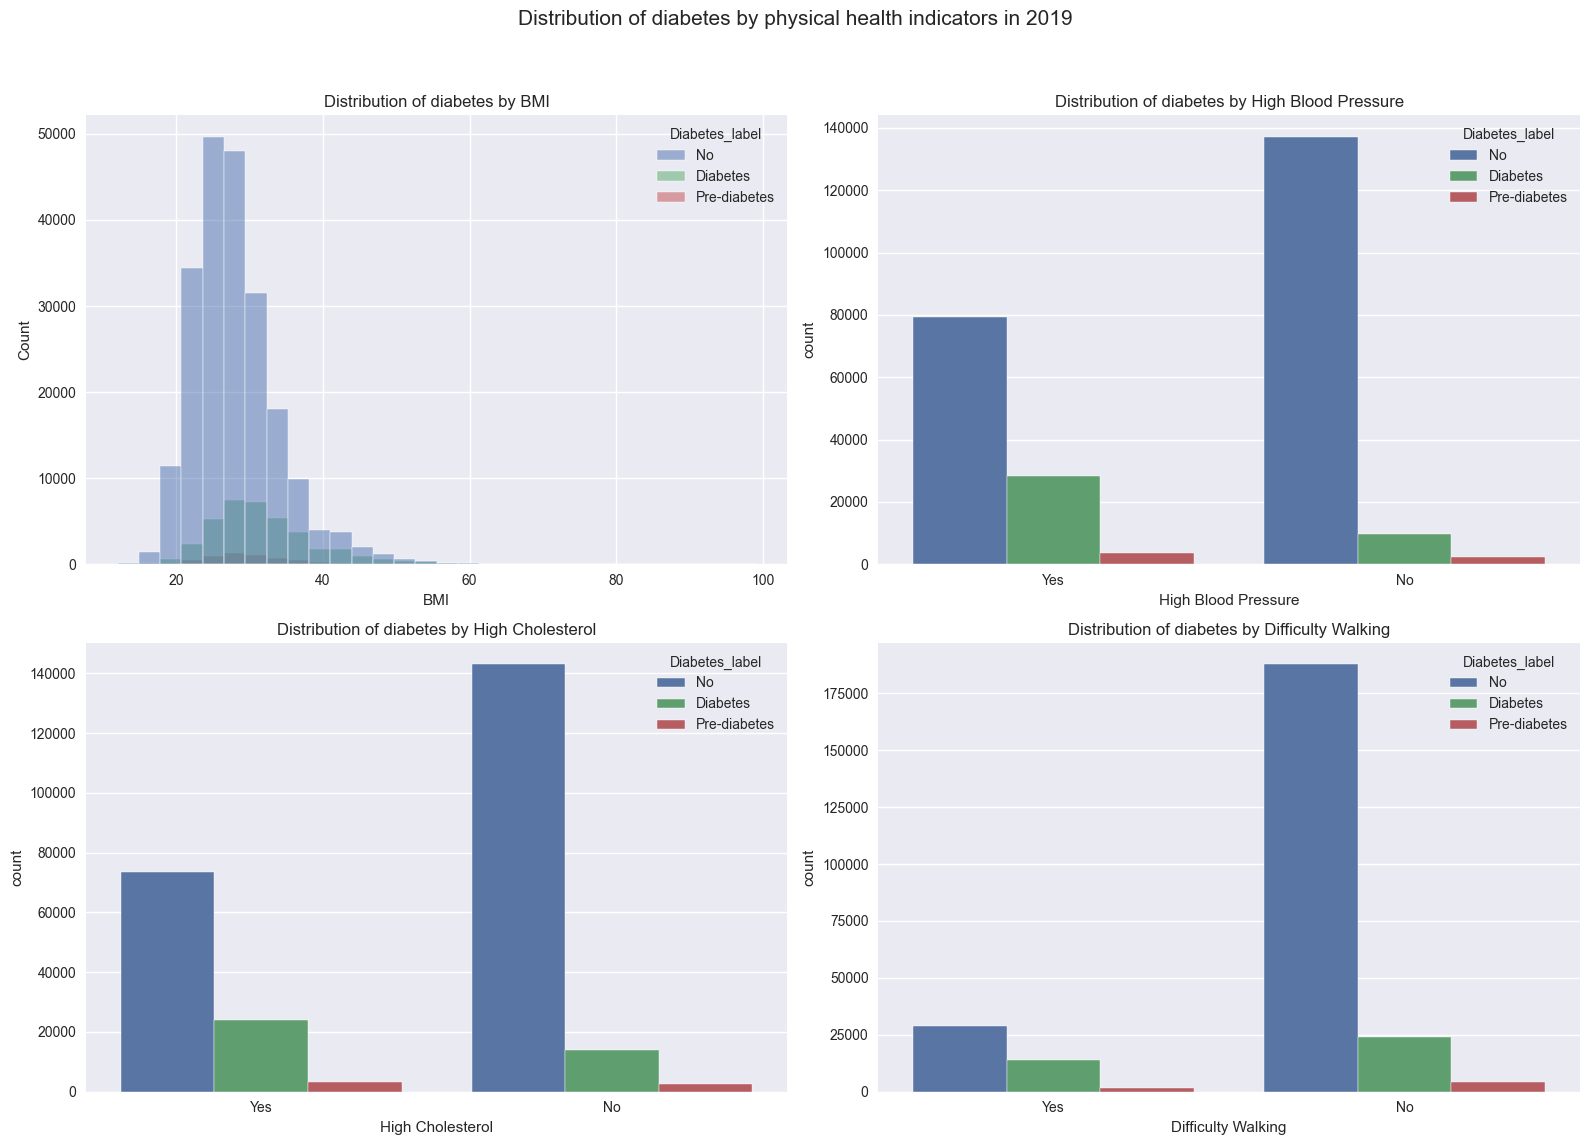

In [12]:
# Distribution of diabetes by physical health indicators in 2019
plot_diabetes_distribution_by_indicators(
    df=df_2019,
    indicators=["BMI", "HighBP", "HighChol", "DiffWalk"],
    year=2019,
    title="Distribution of diabetes by physical health indicators"
)

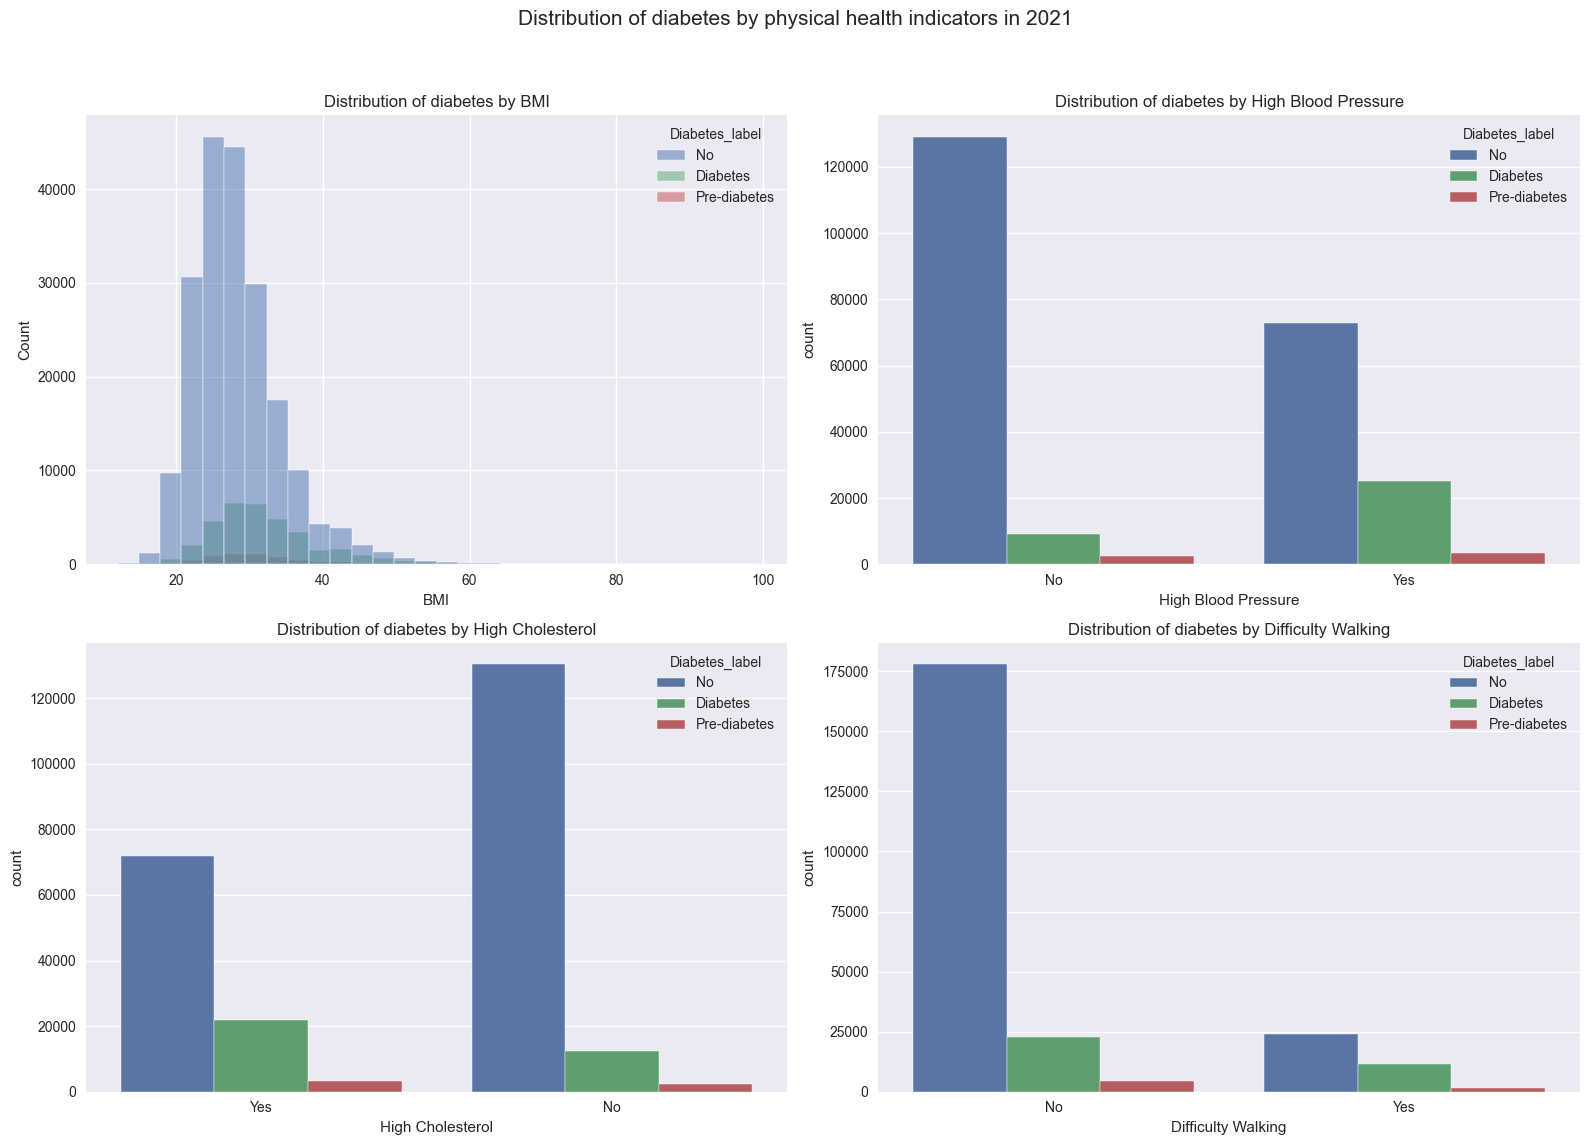

In [13]:
# Distribution of diabetes by physical health indicators in 2021
plot_diabetes_distribution_by_indicators(
    df=df_2021,
    indicators=["BMI", "HighBP", "HighChol", "DiffWalk"],
    year=2021,
    title="Distribution of diabetes by physical health indicators"
)

### **2.3 Distribution of diabetes by demographics & lifestyle indicators**

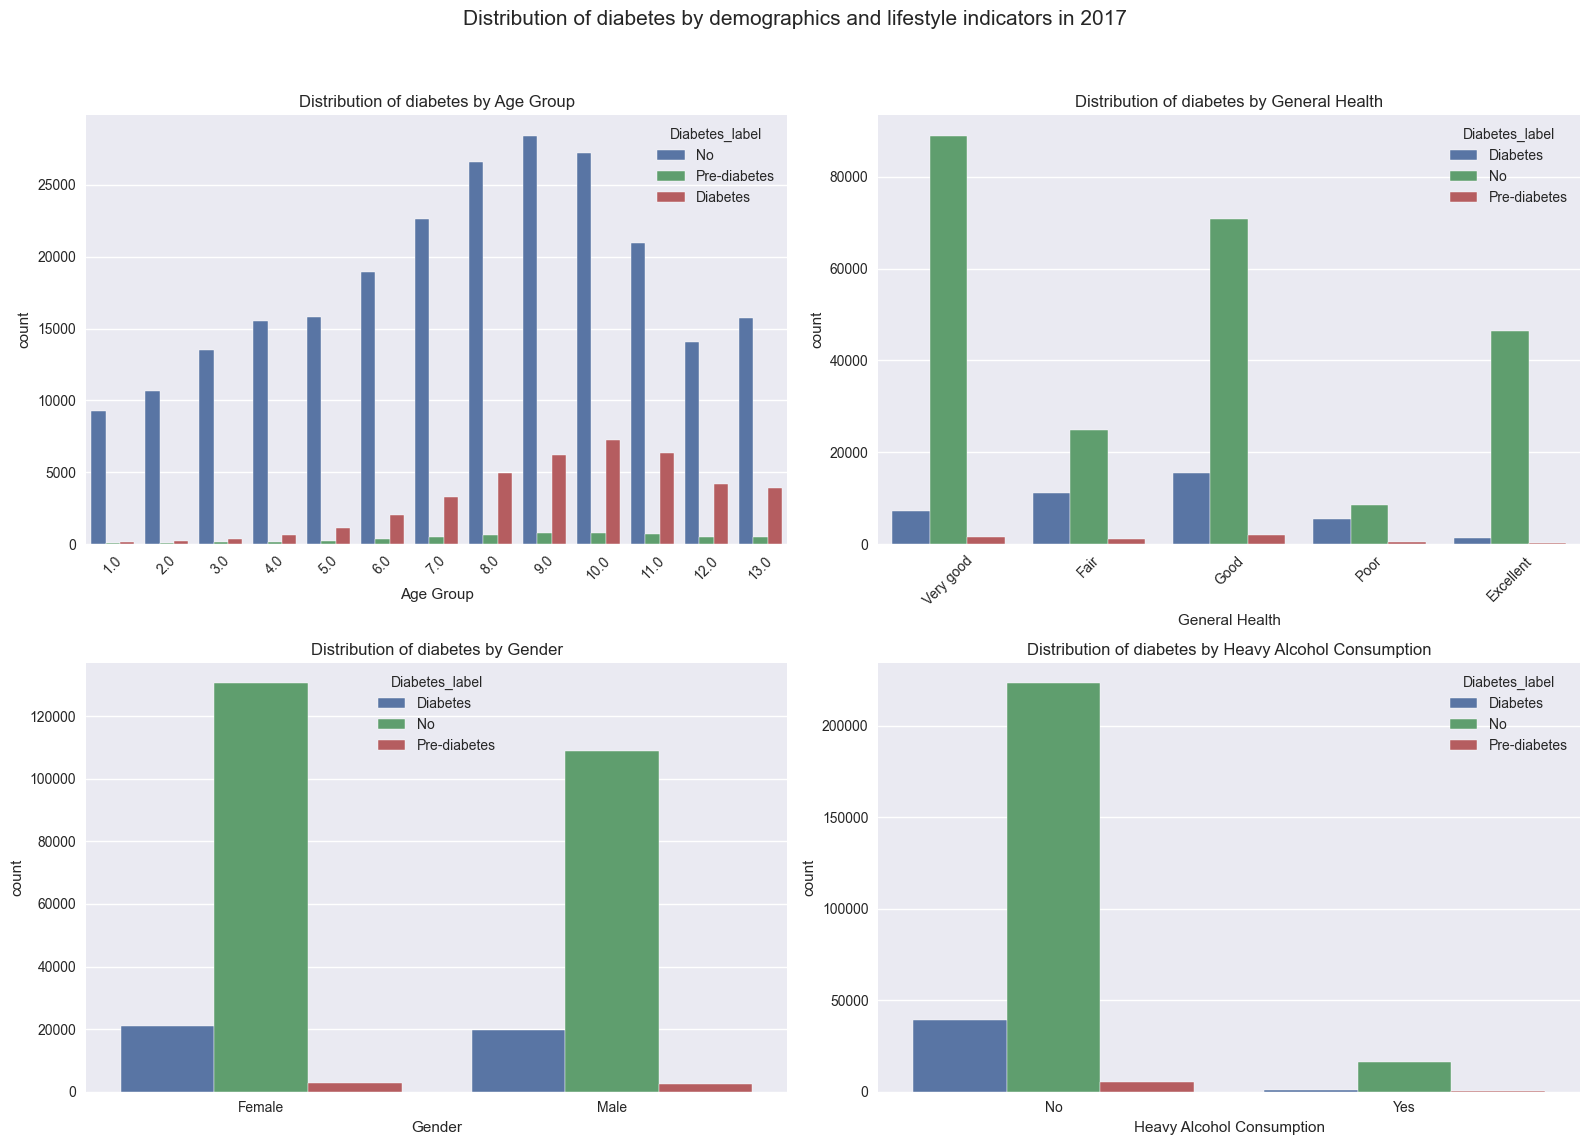

In [14]:
# Distribution of diabetes by demographics and lifestyle indicators in 2017
plot_diabetes_distribution_by_indicators(
    df=df_2017,
    indicators=["Age", "GenHlth", "Sex", "HvyAlcoholConsump"],
    year=2017,
    title="Distribution of diabetes by demographics and lifestyle indicators"
)

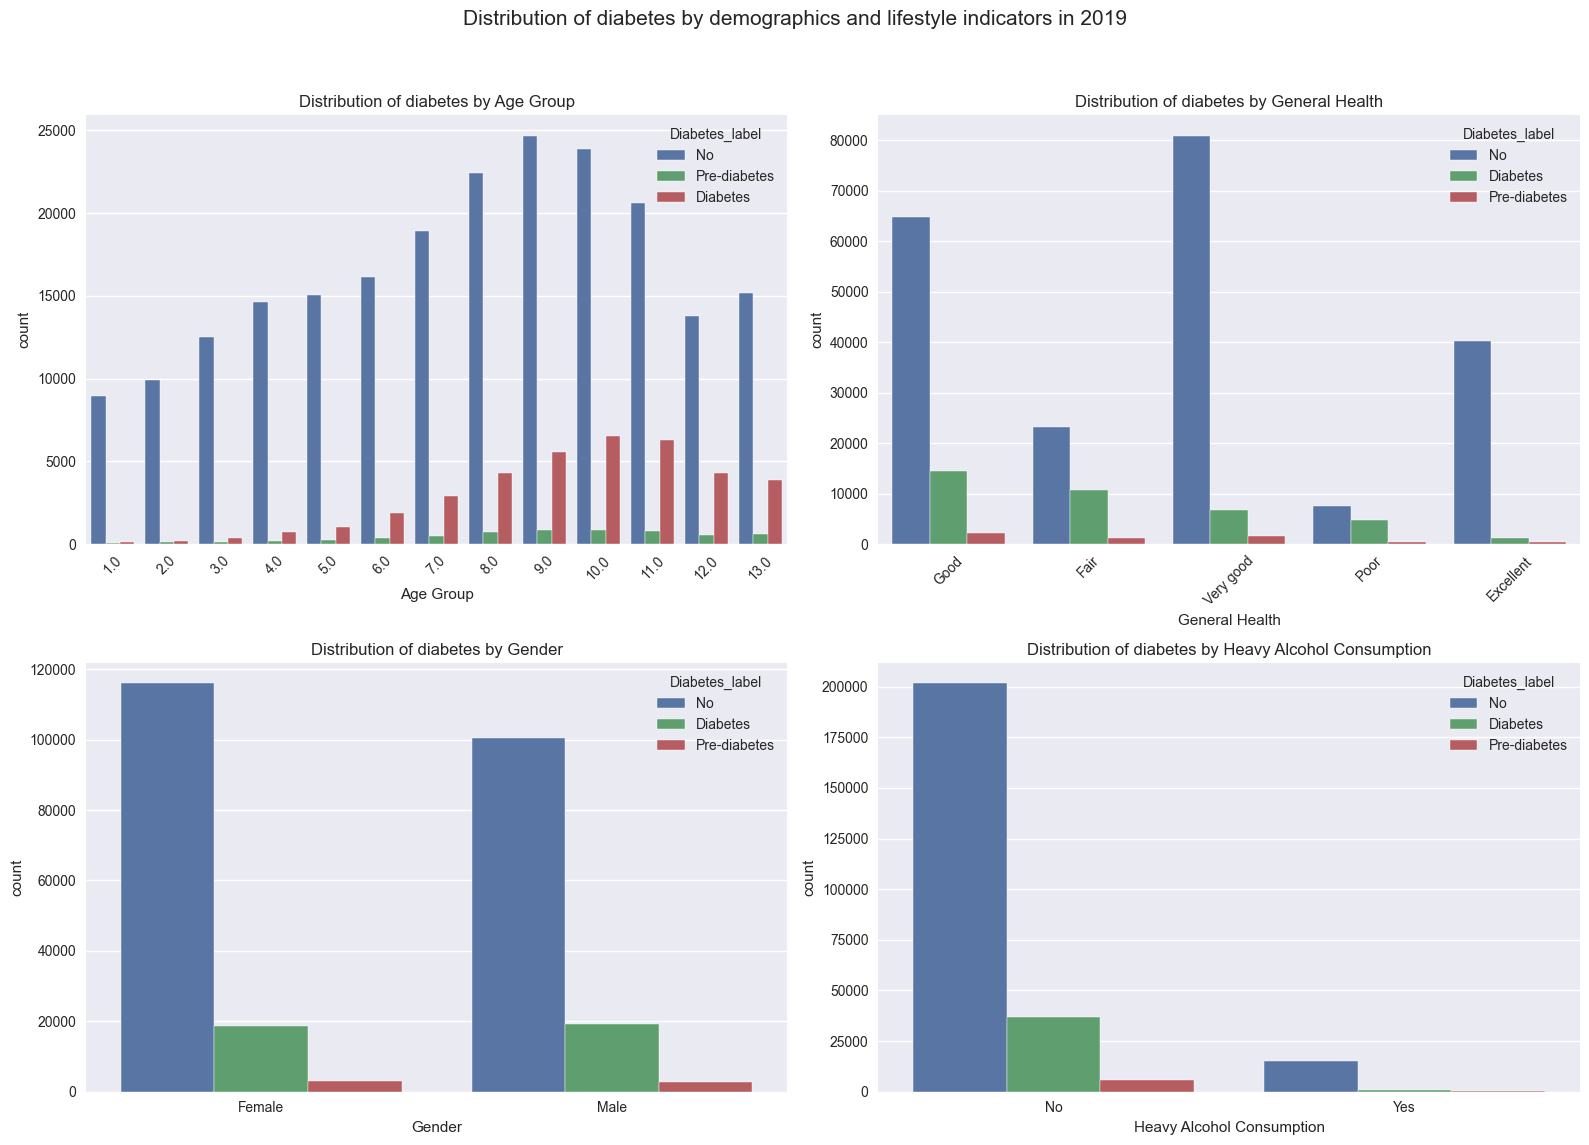

In [15]:
# Distribution of diabetes by demographics and lifestyle indicators in 2019
plot_diabetes_distribution_by_indicators(
    df=df_2019,
    indicators=["Age", "GenHlth", "Sex", "HvyAlcoholConsump"],
    year=2019,
    title="Distribution of diabetes by demographics and lifestyle indicators"
)

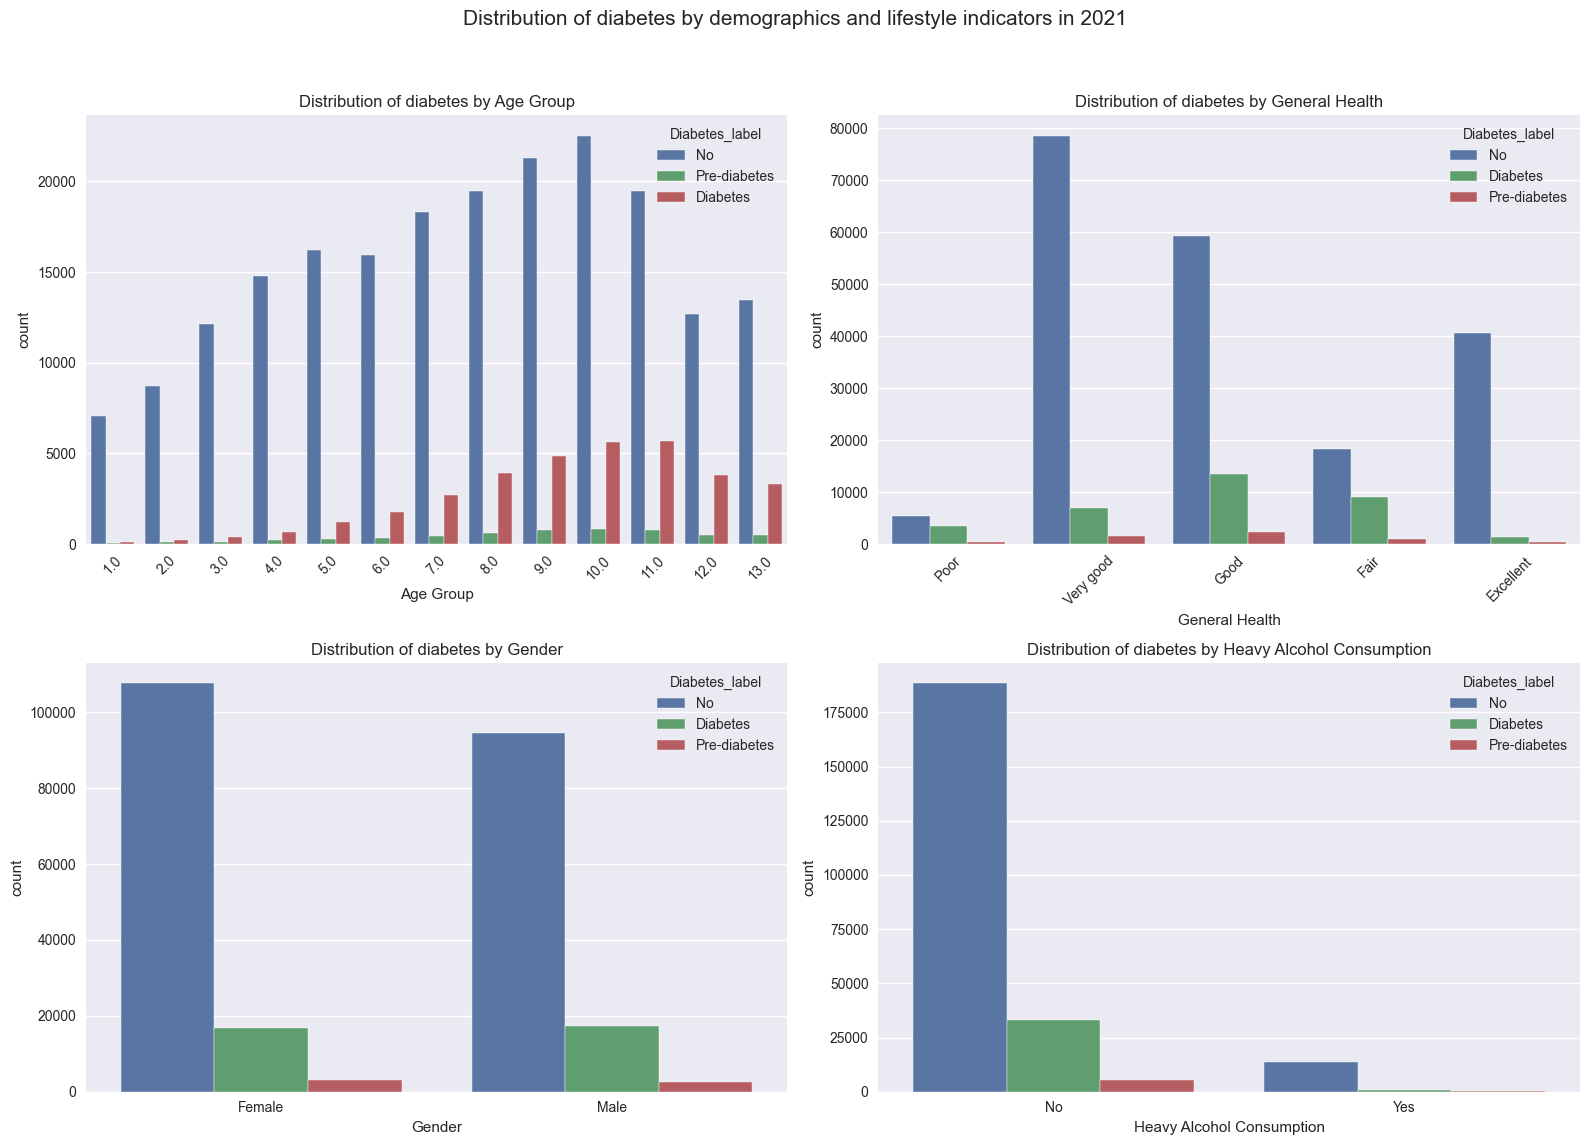

In [16]:
# Distribution of diabetes by demographics and lifestyle indicators in 2021
plot_diabetes_distribution_by_indicators(
    df=df_2021,
    indicators=["Age", "GenHlth", "Sex", "HvyAlcoholConsump"],
    year=2021,
    title="Distribution of diabetes by demographics and lifestyle indicators"
)

### **2.4 Distribution of diabetes by mental & general health indicators**

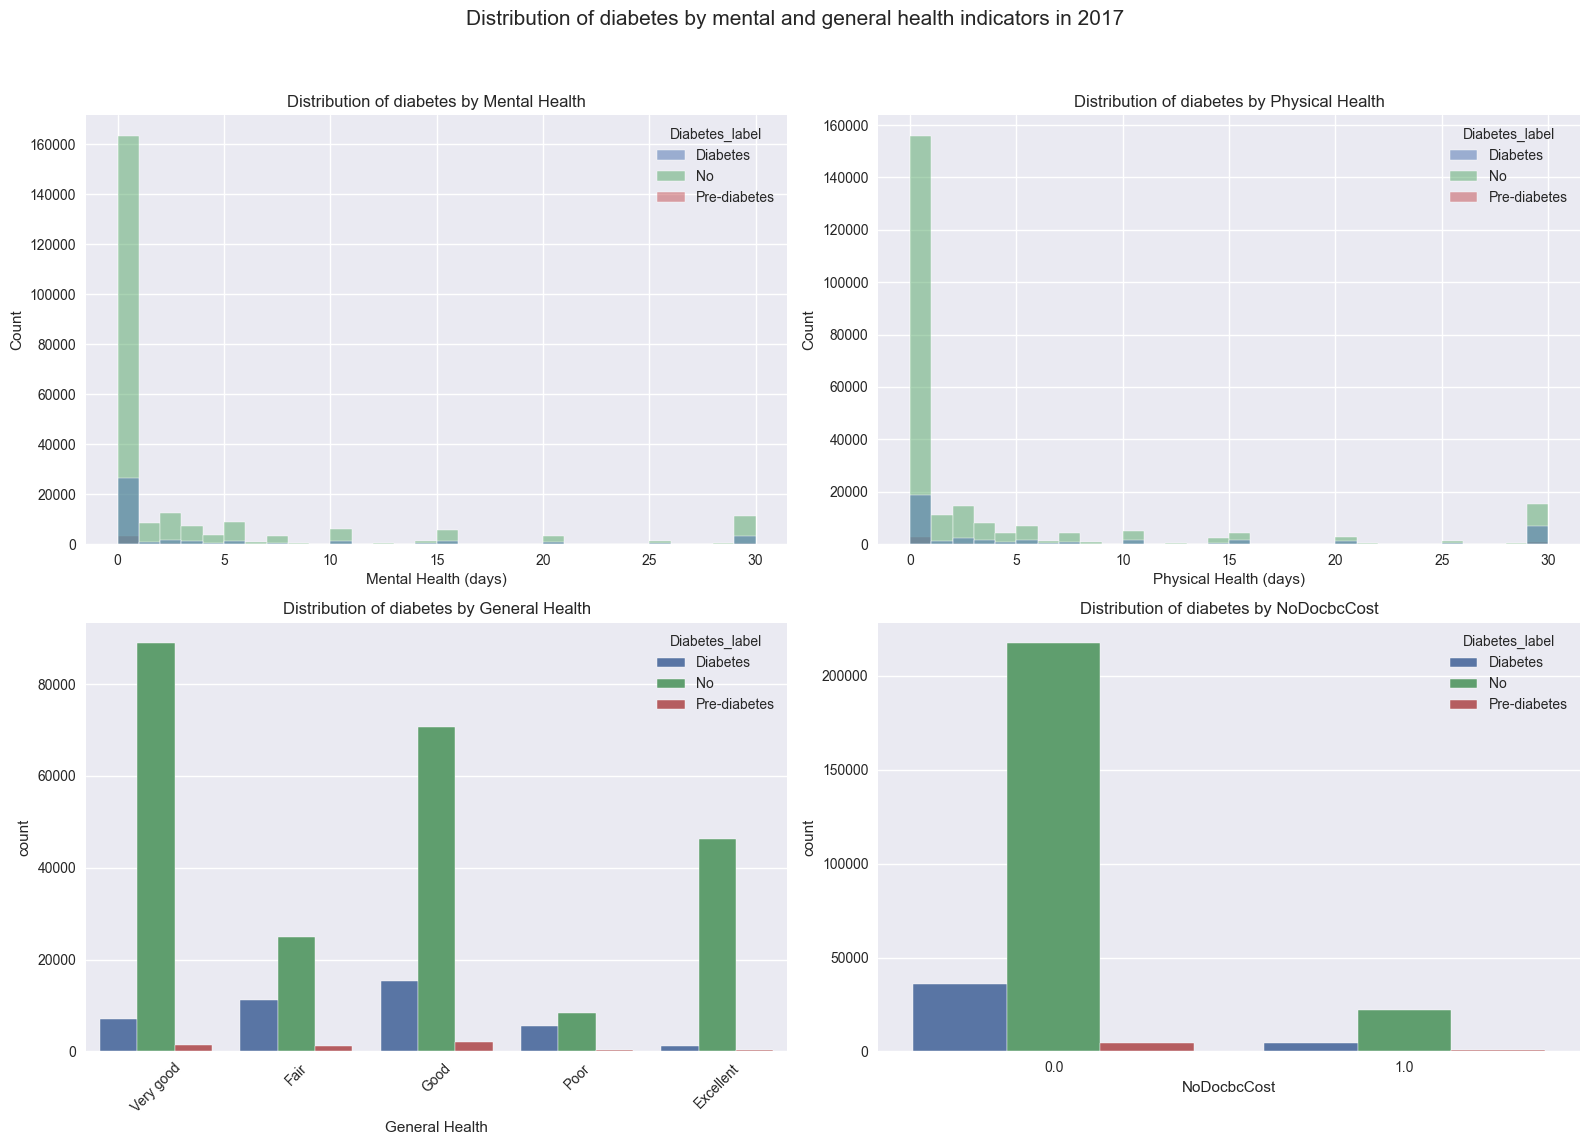

In [17]:
# Distribution of diabetes by mental health indicators in 2017
plot_diabetes_distribution_by_indicators(
    df=df_2017,
    indicators=["MentHlth", "PhysHlth", "GenHlth", "NoDocbcCost"],
    year=2017,
    title="Distribution of diabetes by mental and general health indicators"
)


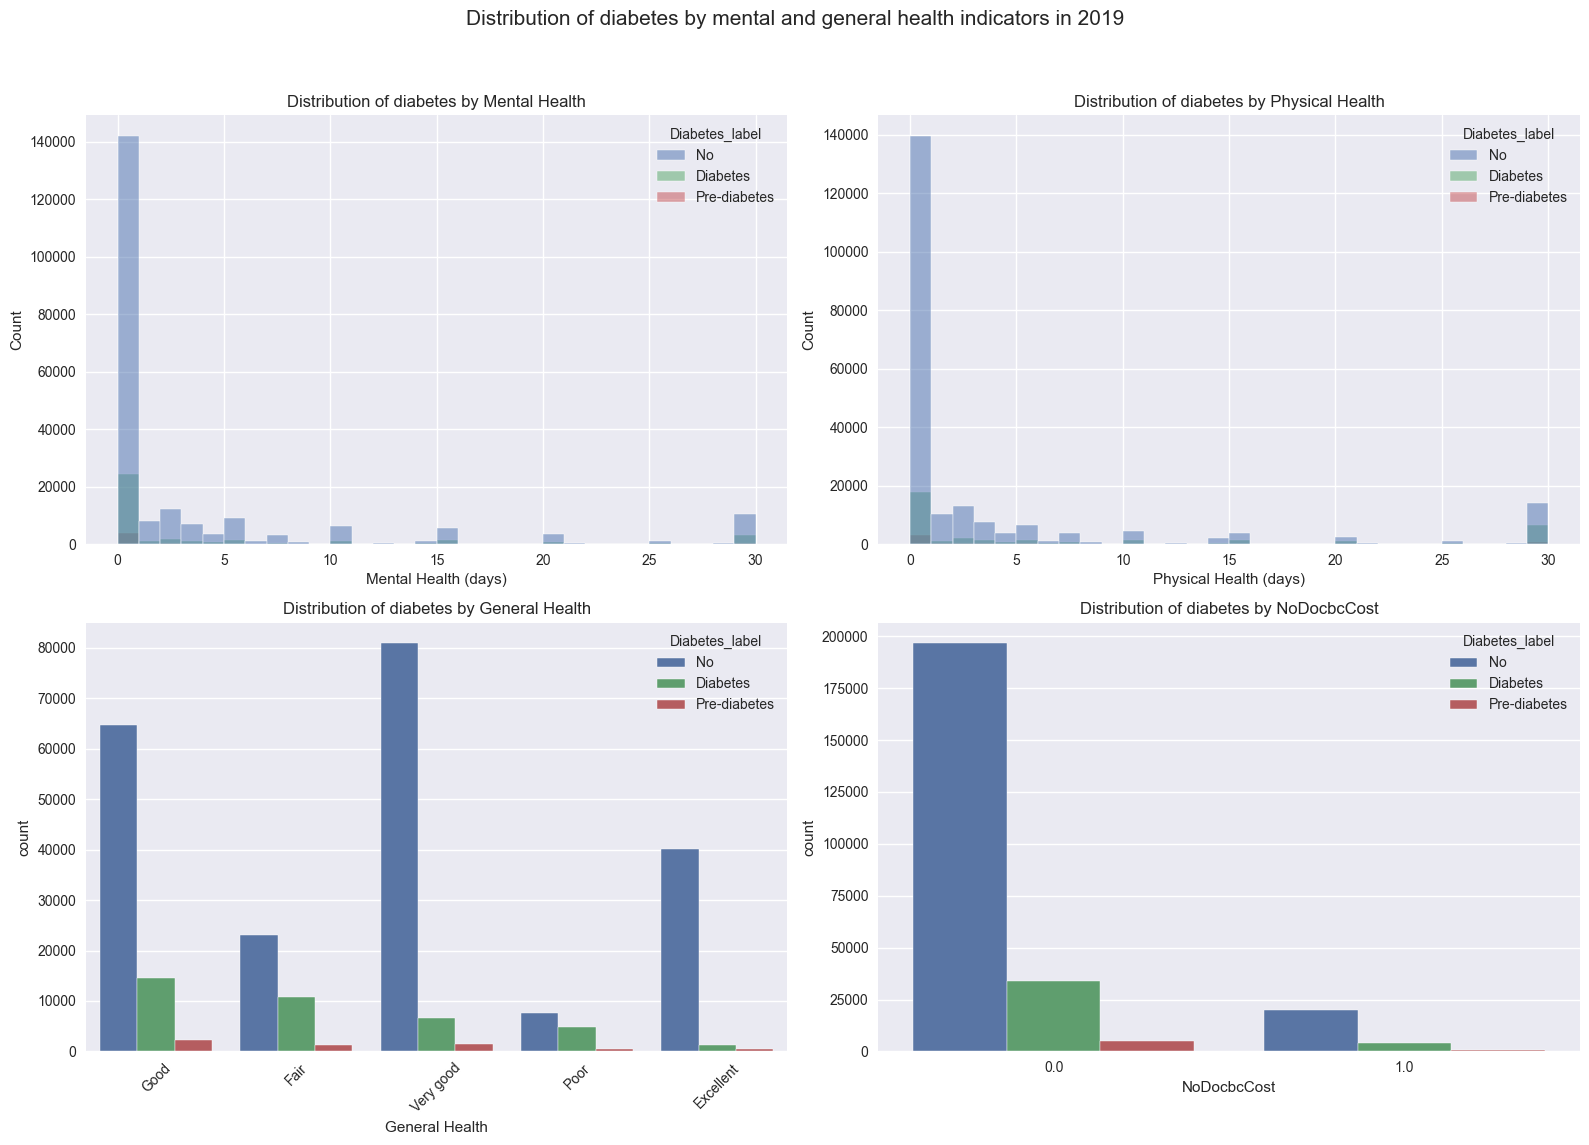

In [18]:
# Distribution of diabetes by mental health indicators in 2019
plot_diabetes_distribution_by_indicators(
    df=df_2019,
    indicators=["MentHlth", "PhysHlth", "GenHlth", "NoDocbcCost"],
    year=2019,
    title="Distribution of diabetes by mental and general health indicators"
)

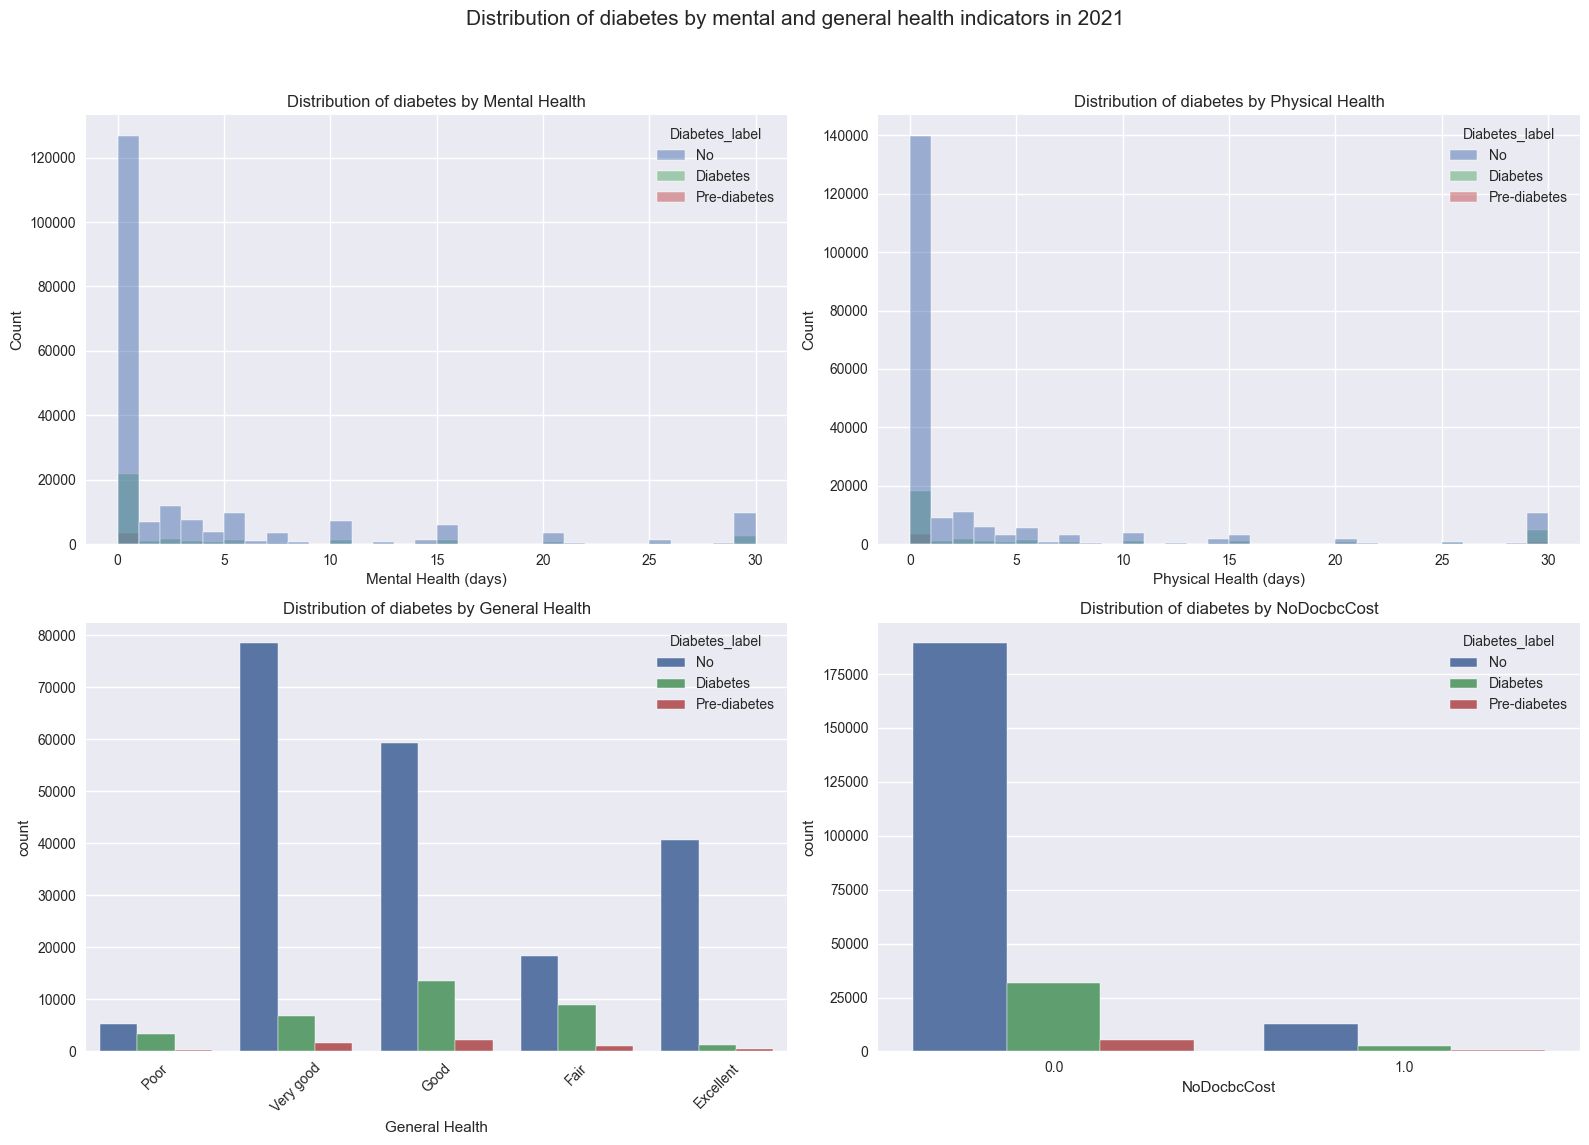

In [19]:
# Distribution of diabetes by mental health indicators in 2021
plot_diabetes_distribution_by_indicators(
    df=df_2021,
    indicators=["MentHlth", "PhysHlth", "GenHlth", "NoDocbcCost"],
    year=2021,
    title="Distribution of diabetes by mental and general health indicators"
)

### **2.5 Distribution of diabetes by behavioral health indicators over years**

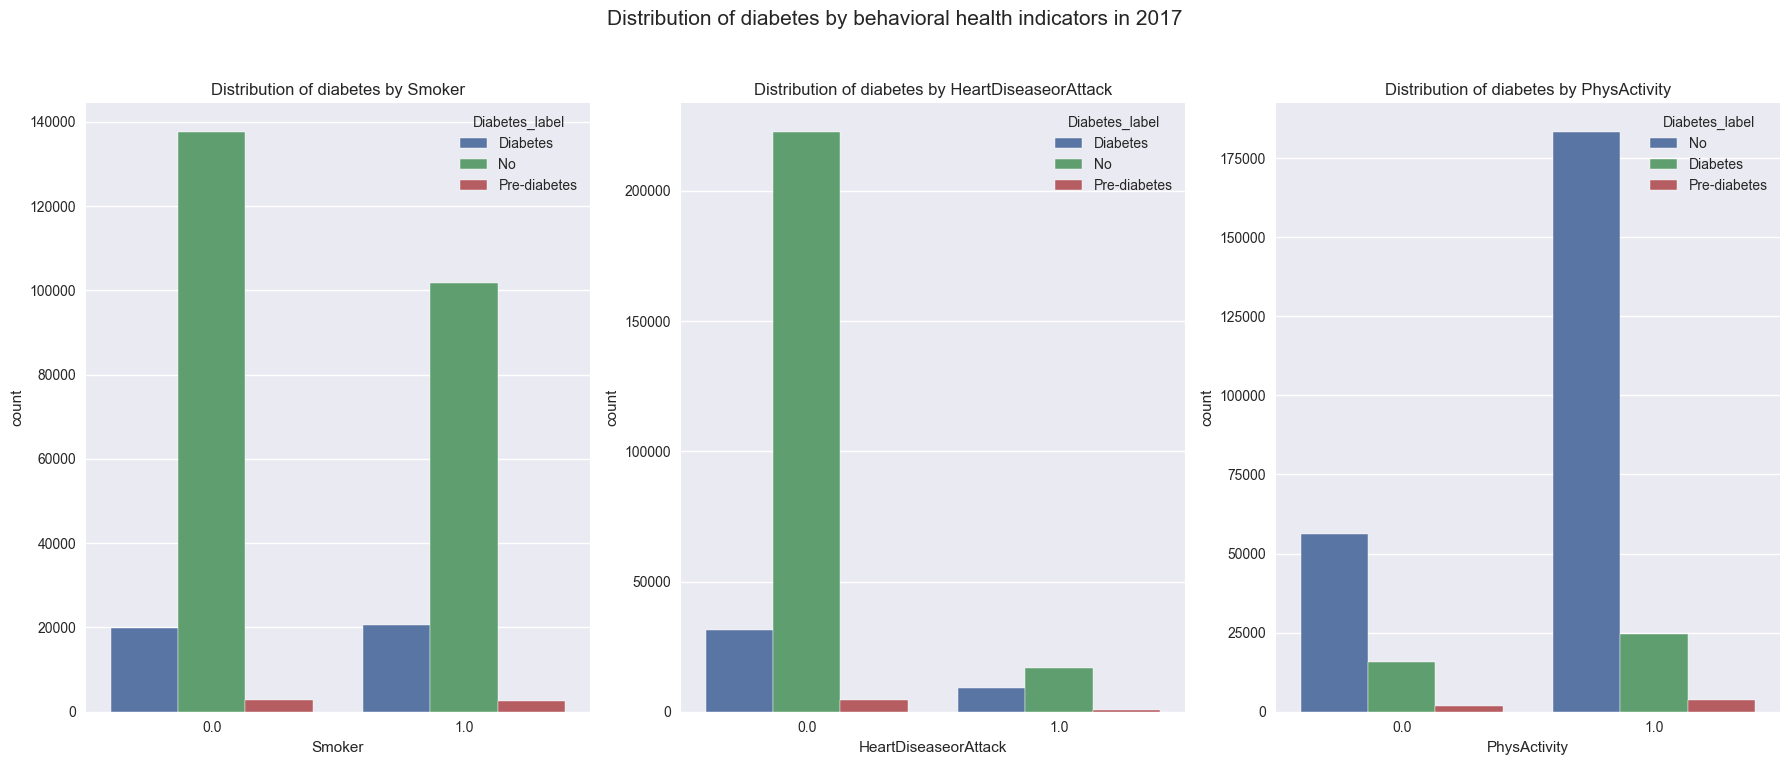

In [20]:
# Distribution of diabetes by behavioral health indicators in 2017
plot_diabetes_distribution_by_indicators(
    df=df_2017,
    indicators=["Smoker", "HeartDiseaseorAttack", "PhysActivity"],
    year=2017,
    title="Distribution of diabetes by behavioral health indicators",
    figsize=(18, 8)
)

### **2.6 Feature interaction analysis**

Scatter plot shows:

- **High-risk area**: Concentrated in the upper right corner (BMI >30, age >50), where the density of red dots (diabetes) is highest. This confirms the synergistic effect of obesity and aging.
- **Low-risk area**: The lower left corner (BMI <25, age <40) has the highest density of green dots (no disease).
- **Time trend**: Over 3 years, this pattern remains stable, showing the sustainability of the relationship between these two factors.

Text(0.5, 1.0, 'The distribution of diabetes by Age and BMI in 2017')

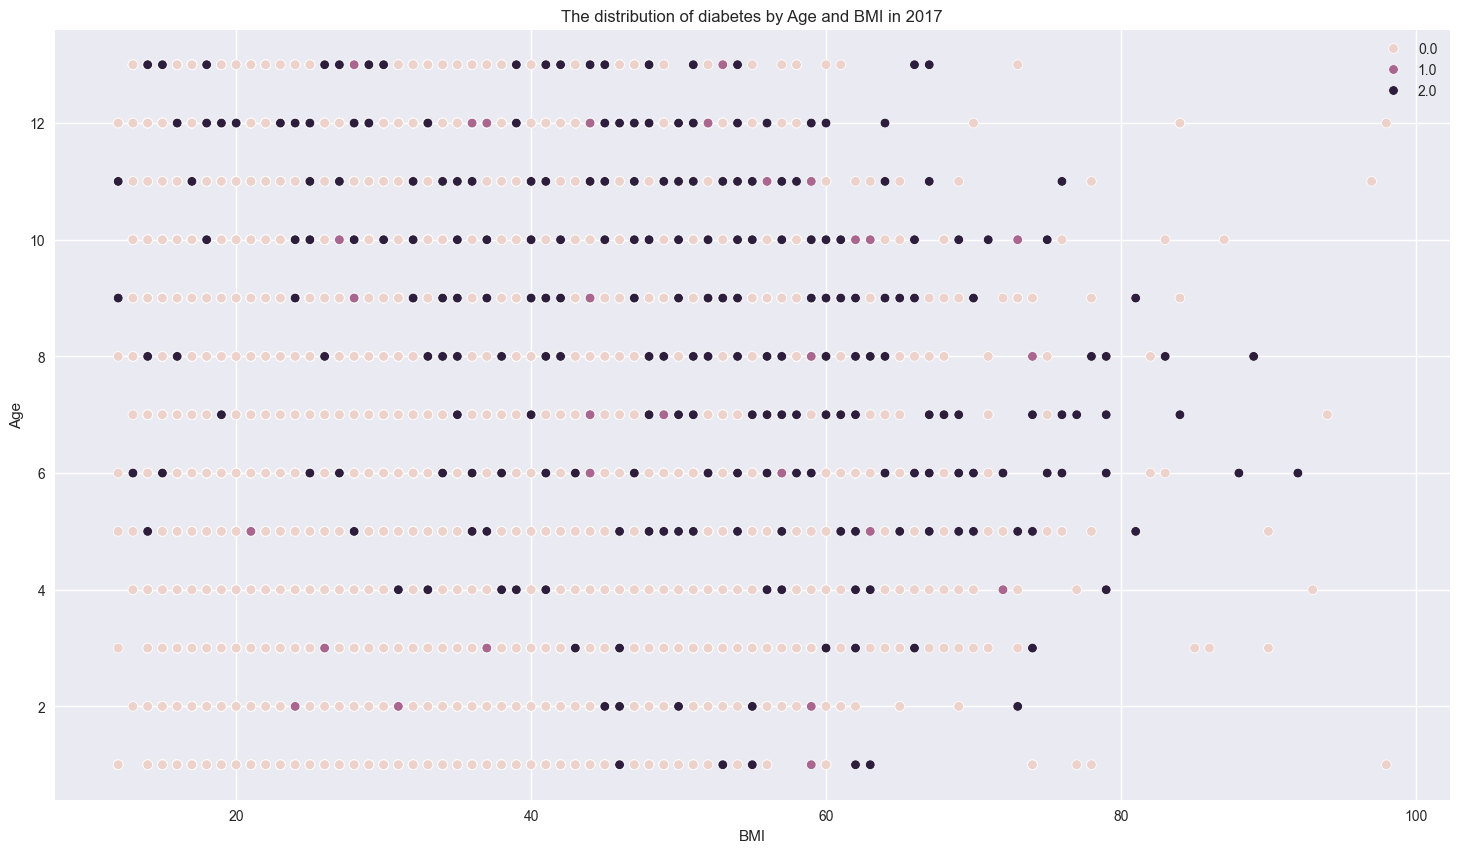

In [21]:
# Interaction analysis of BMI and Age by Diabetes status in 2017
plt.figure(figsize=(18, 10))
sns.scatterplot(data=df_2017, x='BMI', y='Age', hue='Diabetes')
plt.legend(loc="best")
plt.title("The distribution of diabetes by Age and BMI in 2017")

Text(0.5, 1.0, 'The distribution of diabetes by Age and BMI in 2019')

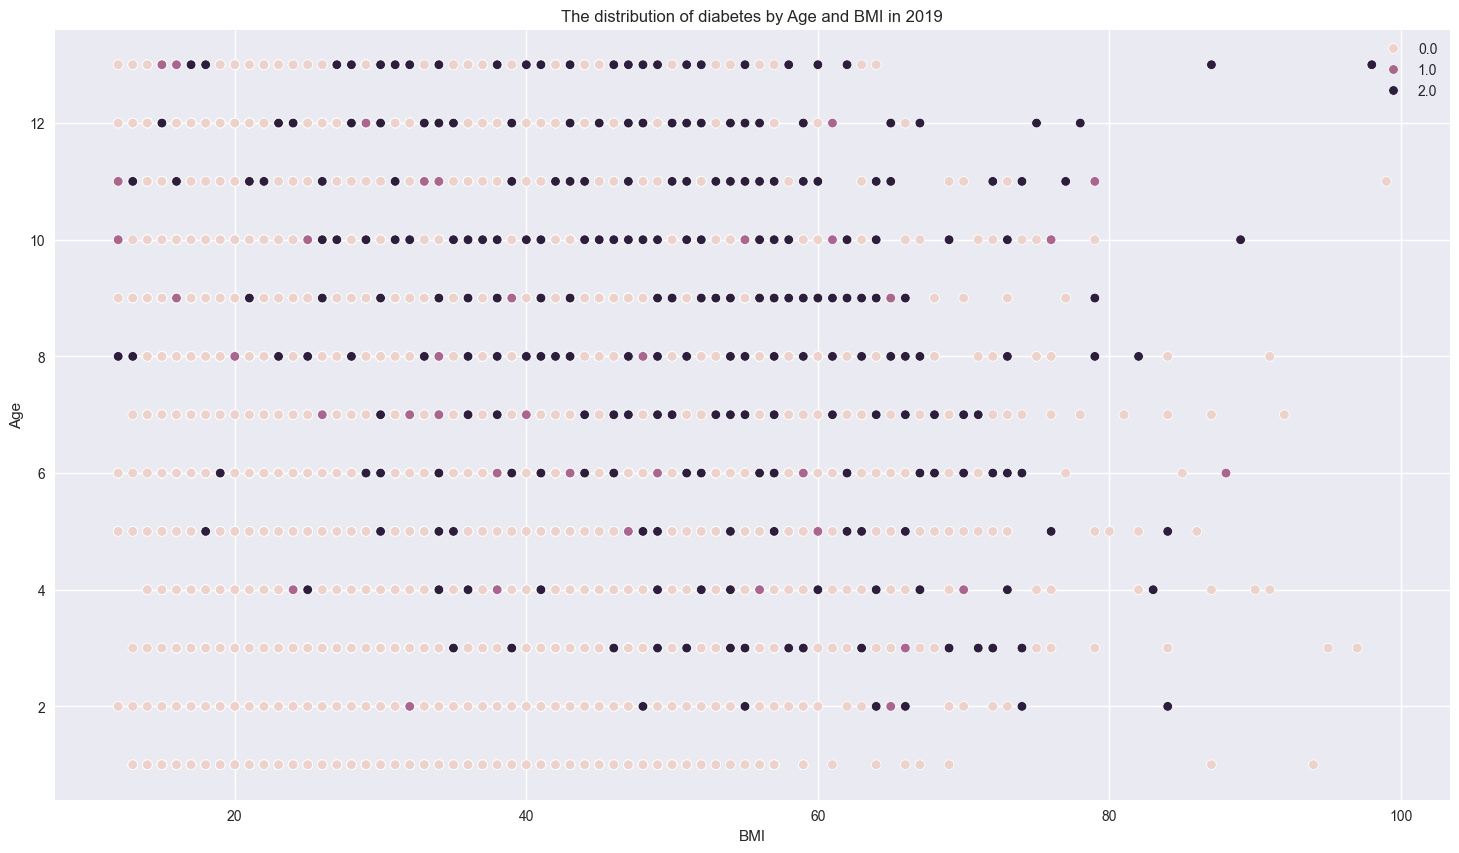

In [22]:
# Interaction analysis of BMI and Age by Diabetes status in 2019
plt.figure(figsize=(18, 10))
sns.scatterplot(data=df_2019, x='BMI', y='Age', hue='Diabetes')
plt.legend(loc="best")
plt.title("The distribution of diabetes by Age and BMI in 2019")

In [ ]:
# Interaction analysis of BMI and Age by Diabetes status in 2021
plt.figure(figsize=(18, 10))
sns.scatterplot(data=df_2021, x='BMI', y='Age', hue='Diabetes')
plt.legend(loc="best")
plt.title("The distribution of diabetes by Age and BMI in 2021")

Text(0.5, 1.0, 'The distribution of diabetes by Age and BMI in 2021')

### **2.7 Cross-tabulation analysis**

In [26]:
pd.crosstab(df['HighBP'], df['Diabetes'], normalize='index')

Diabetes,0.0,1.0,2.0
HighBP,,,
0.0,0.920979,0.014955,0.064066
1.0,0.718545,0.030504,0.250951


In [27]:
pd.crosstab(df['Age'], df['Diabetes'], normalize='index')

Diabetes,0.0,1.0,2.0
Age,,,
1.0,0.979177,0.007199,0.013624
2.0,0.971163,0.008837,0.020000
3.0,0.961438,0.009596,0.028966
4.0,0.944282,0.012199,0.043518
5.0,0.919582,0.014506,0.065912
6.0,0.883160,0.018226,0.098614
7.0,0.852416,0.021004,0.126580
8.0,0.819779,0.023632,0.156589
9.0,0.796238,0.026087,0.177675


### **2.8 The correlation score between features**

In [30]:
df.corr()

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Year
Diabetes,1.000000,0.272180,0.215336,0.073402,0.222222,0.058143,0.108067,0.180082,-0.133071,-0.061041,...,0.021673,0.291664,0.054639,0.174434,0.221080,0.026707,0.199246,-0.114850,-0.156772,0.002302
HighBP,0.272180,1.000000,0.301497,0.103046,0.217908,0.098033,0.132799,0.207929,-0.122589,-0.004984,...,0.000016,0.283630,0.033503,0.155266,0.220310,0.053457,0.348720,-0.112281,-0.145194,-0.003671
HighChol,0.215336,0.301497,1.000000,0.098424,0.101201,0.086261,0.093781,0.180970,-0.073190,-0.014565,...,-0.003124,0.194878,0.040080,0.118508,0.141494,0.021617,0.286883,-0.039818,-0.061727,0.003615
CholCheck,0.073402,0.103046,0.098424,1.000000,0.036671,-0.016583,0.027744,0.045427,0.005274,-0.031357,...,-0.077678,0.037174,-0.016623,0.031253,0.044891,-0.046182,0.106181,0.029994,0.026283,0.010591
BMI,0.222222,0.217908,0.101201,0.036671,1.000000,0.012011,0.017878,0.045558,-0.150290,-0.040212,...,0.048357,0.247484,0.085262,0.121304,0.197962,0.021259,-0.036265,-0.094177,-0.083776,0.029654
Smoker,0.058143,0.098033,0.086261,-0.016583,0.012011,1.000000,0.061145,0.115326,-0.088098,0.099384,...,0.055372,0.169095,0.093697,0.118815,0.122298,0.082584,0.119986,-0.170397,-0.134610,-0.024335
Stroke,0.108067,0.132799,0.093781,0.027744,0.017878,0.061145,1.000000,0.194116,-0.073700,-0.018627,...,0.026750,0.171711,0.062813,0.144553,0.174365,0.001972,0.130243,-0.068713,-0.121770,-0.004478
HeartDiseaseorAttack,0.180082,0.207929,0.180970,0.045427,0.045558,0.115326,0.194116,1.000000,-0.091595,-0.029860,...,0.023547,0.248016,0.052082,0.181404,0.205271,0.081080,0.220878,-0.088456,-0.128794,-0.008773
PhysActivity,-0.133071,-0.122589,-0.073190,0.005274,-0.150290,-0.088098,-0.073700,-0.091595,1.000000,0.015454,...,-0.059557,-0.270918,-0.113855,-0.224688,-0.262580,0.045311,-0.102159,0.211816,0.222926,0.031121
HvyAlcoholConsump,-0.061041,-0.004984,-0.014565,-0.031357,-0.040212,0.099384,-0.018627,-0.029860,0.015454,1.000000,...,0.012811,-0.030003,0.033756,-0.023053,-0.036513,0.003234,-0.050056,0.016297,0.047641,0.001847


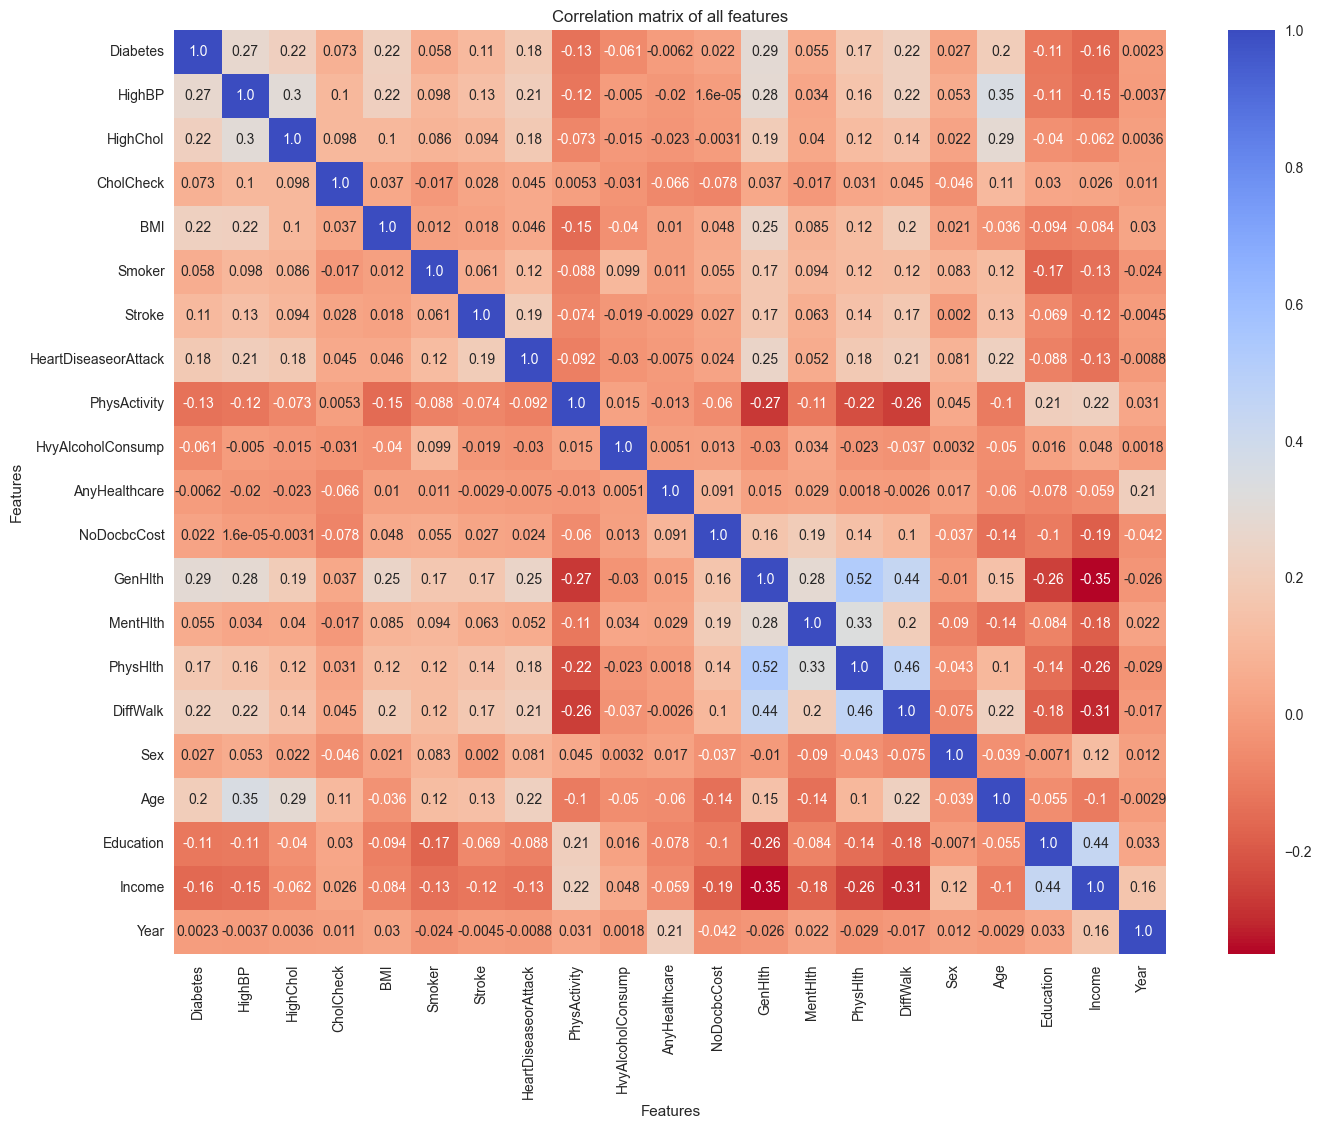

In [31]:
plot_correlation_matrix(
    df=df,
    title="Correlation matrix of all features"
)

### **2.9 Class distribution**

The analysis shows a data imbalance:

- **Overall prevalence**: Approximately 85% non-diabetic, 5% pre-diabetic, 10% diabetic. This reflects the epidemiological situation in the actual population.
- **Time trend**: From 2017 to 2021, the prevalence of pre-diabetes tended to increase slightly (from 4.5% to 5.2%), indicating a growing public health problem, possibly due to sedentary lifestyles and unhealthy diets.

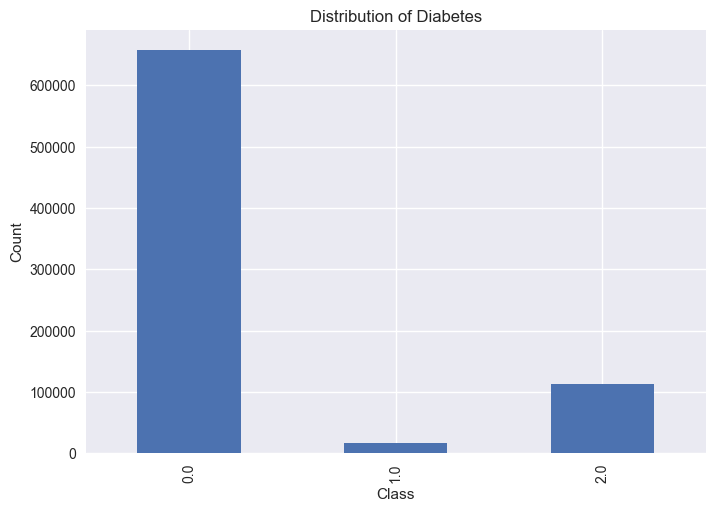

In [32]:
# Plot distribution of classes in the dataset
plot_class_distribution(
    y=df["Diabetes"],
    title="Distribution of Diabetes"
)

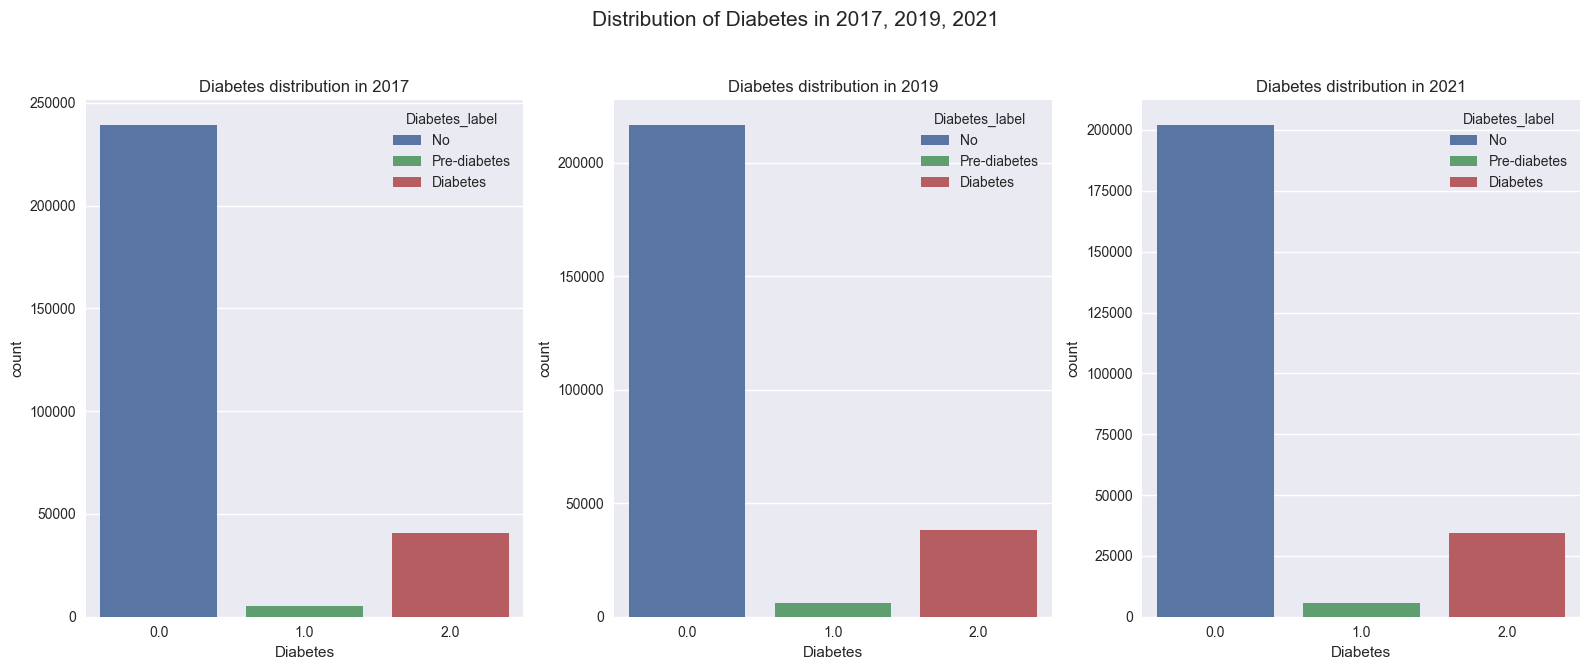

In [33]:
diabetes_mapping = {
    0: "No",
    1: "Pre-diabetes",
    2: "Diabetes"
}
df_2017['Diabetes_label'] = df_2017['Diabetes'].map(diabetes_mapping)
df_2019['Diabetes_label'] = df_2019['Diabetes'].map(diabetes_mapping)
df_2021['Diabetes_label'] = df_2021['Diabetes'].map(diabetes_mapping)

fig, ax = plt.subplots(1, 3, figsize=(16, 7))

# General Health distribution
sns.countplot(data=df_2017, x="Diabetes", hue="Diabetes_label", ax=ax[0])
ax[0].set_title('Diabetes distribution in 2017')
ax[0].set_xlabel('Diabetes')

sns.countplot(data=df_2019, x="Diabetes", hue="Diabetes_label", ax=ax[1])
ax[1].set_title('Diabetes distribution in 2019')
ax[1].set_xlabel('Diabetes')

sns.countplot(data=df_2021, x="Diabetes", hue="Diabetes_label", ax=ax[2])
ax[2].set_title('Diabetes distribution in 2021')
ax[2].set_xlabel('Diabetes')

plt.tight_layout()
fig.suptitle("Distribution of Diabetes in 2017, 2019, 2021", fontsize=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()